In [1]:
# Setup and imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# Repo-Root vor dem site-packages-Paket in den sys.path einfügen, damit
# Änderungen am lokalen mdxplain-Code ohne Neuinstallation wirksam werden
PROJECT_ROOT = Path.cwd().resolve().parents[2]  # mdxplain/spec/tests -> repo root
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

from mdxplain import PipelineManager
from mdxplain import SpecManager

import copy
from dev_scripts.visualize_operation_graph import build_figure
from mdxplain.spec.helper.spec_validator_helper import SpecValidatorHelper


# 1. Test pipeline for JSON generation

📦 Creating Zarr cache: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_836639877a6745eaaf857ff6aca8a3a4_20261008_132234/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  🔍 Analyzing trajectory dimensions...
  📐 Trajectory: 10001 frames × 1027 atoms
  💾 Writing trajectory data...
  ✅ Cache created: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_836639877a6745eaaf857ff6aca8a3a4_20261008_132234/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  📊 Size: 89.0 MB

Loaded 1 systems with 1 total trajectories:
  2RJY: 1 trajectories
Loading 117.5 MB coordinate data...
Generated 1953 residue pairs for 64 residues
Created feature selector: 'contacts_only'
Added to selector 'contacts_only': contacts -> 'all' (use_reduced=False, common_denominator=True, traj_selection=all, require_all_partners=False)
Applied feature selector 'contacts_only' with reference trajectory 0 successfully
Starting eigendecomposition for 4 compo

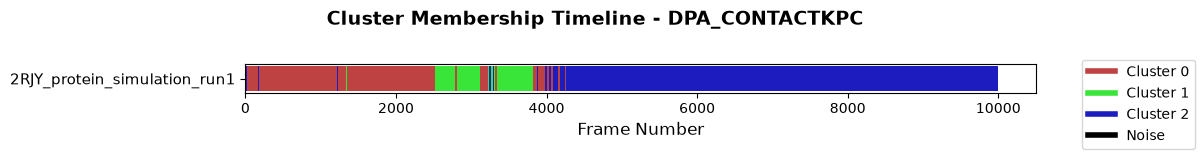

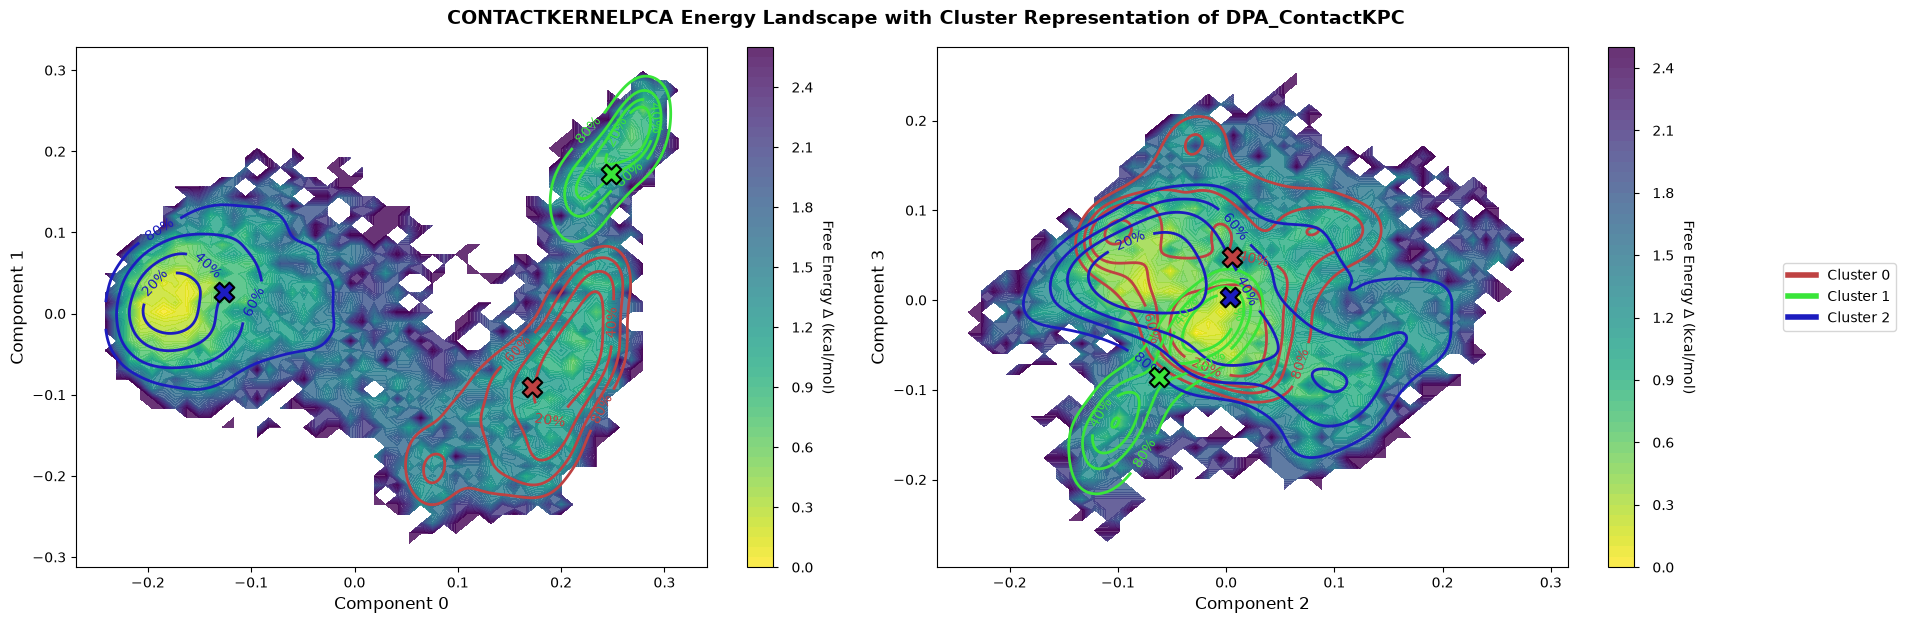

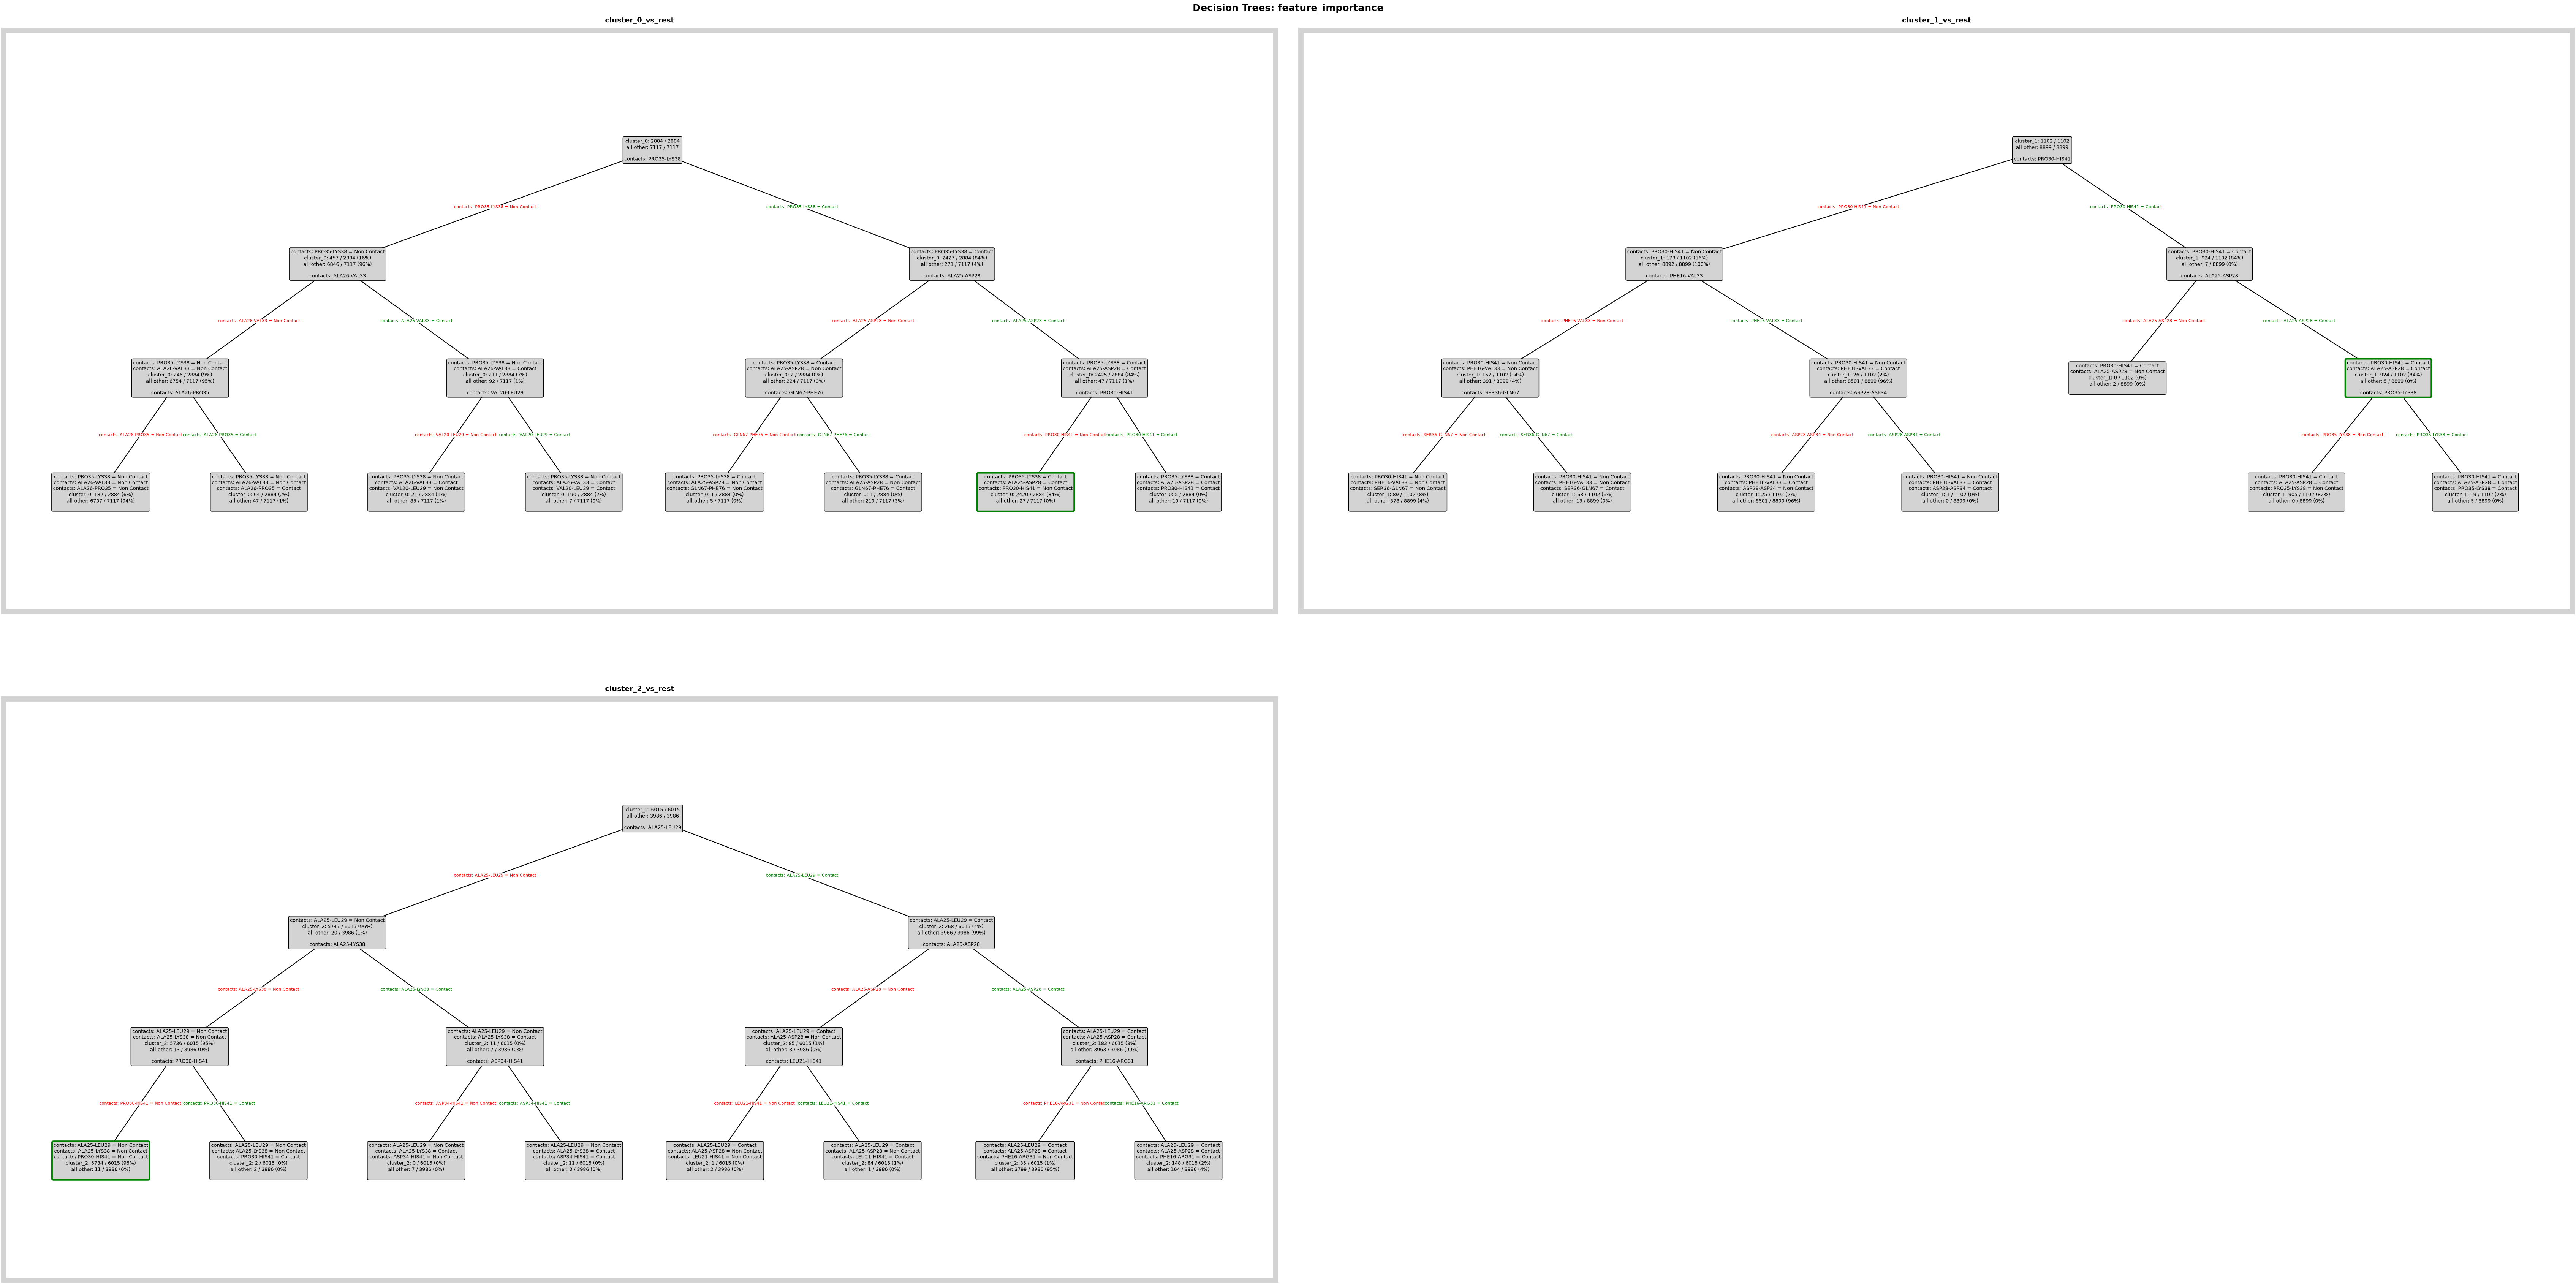

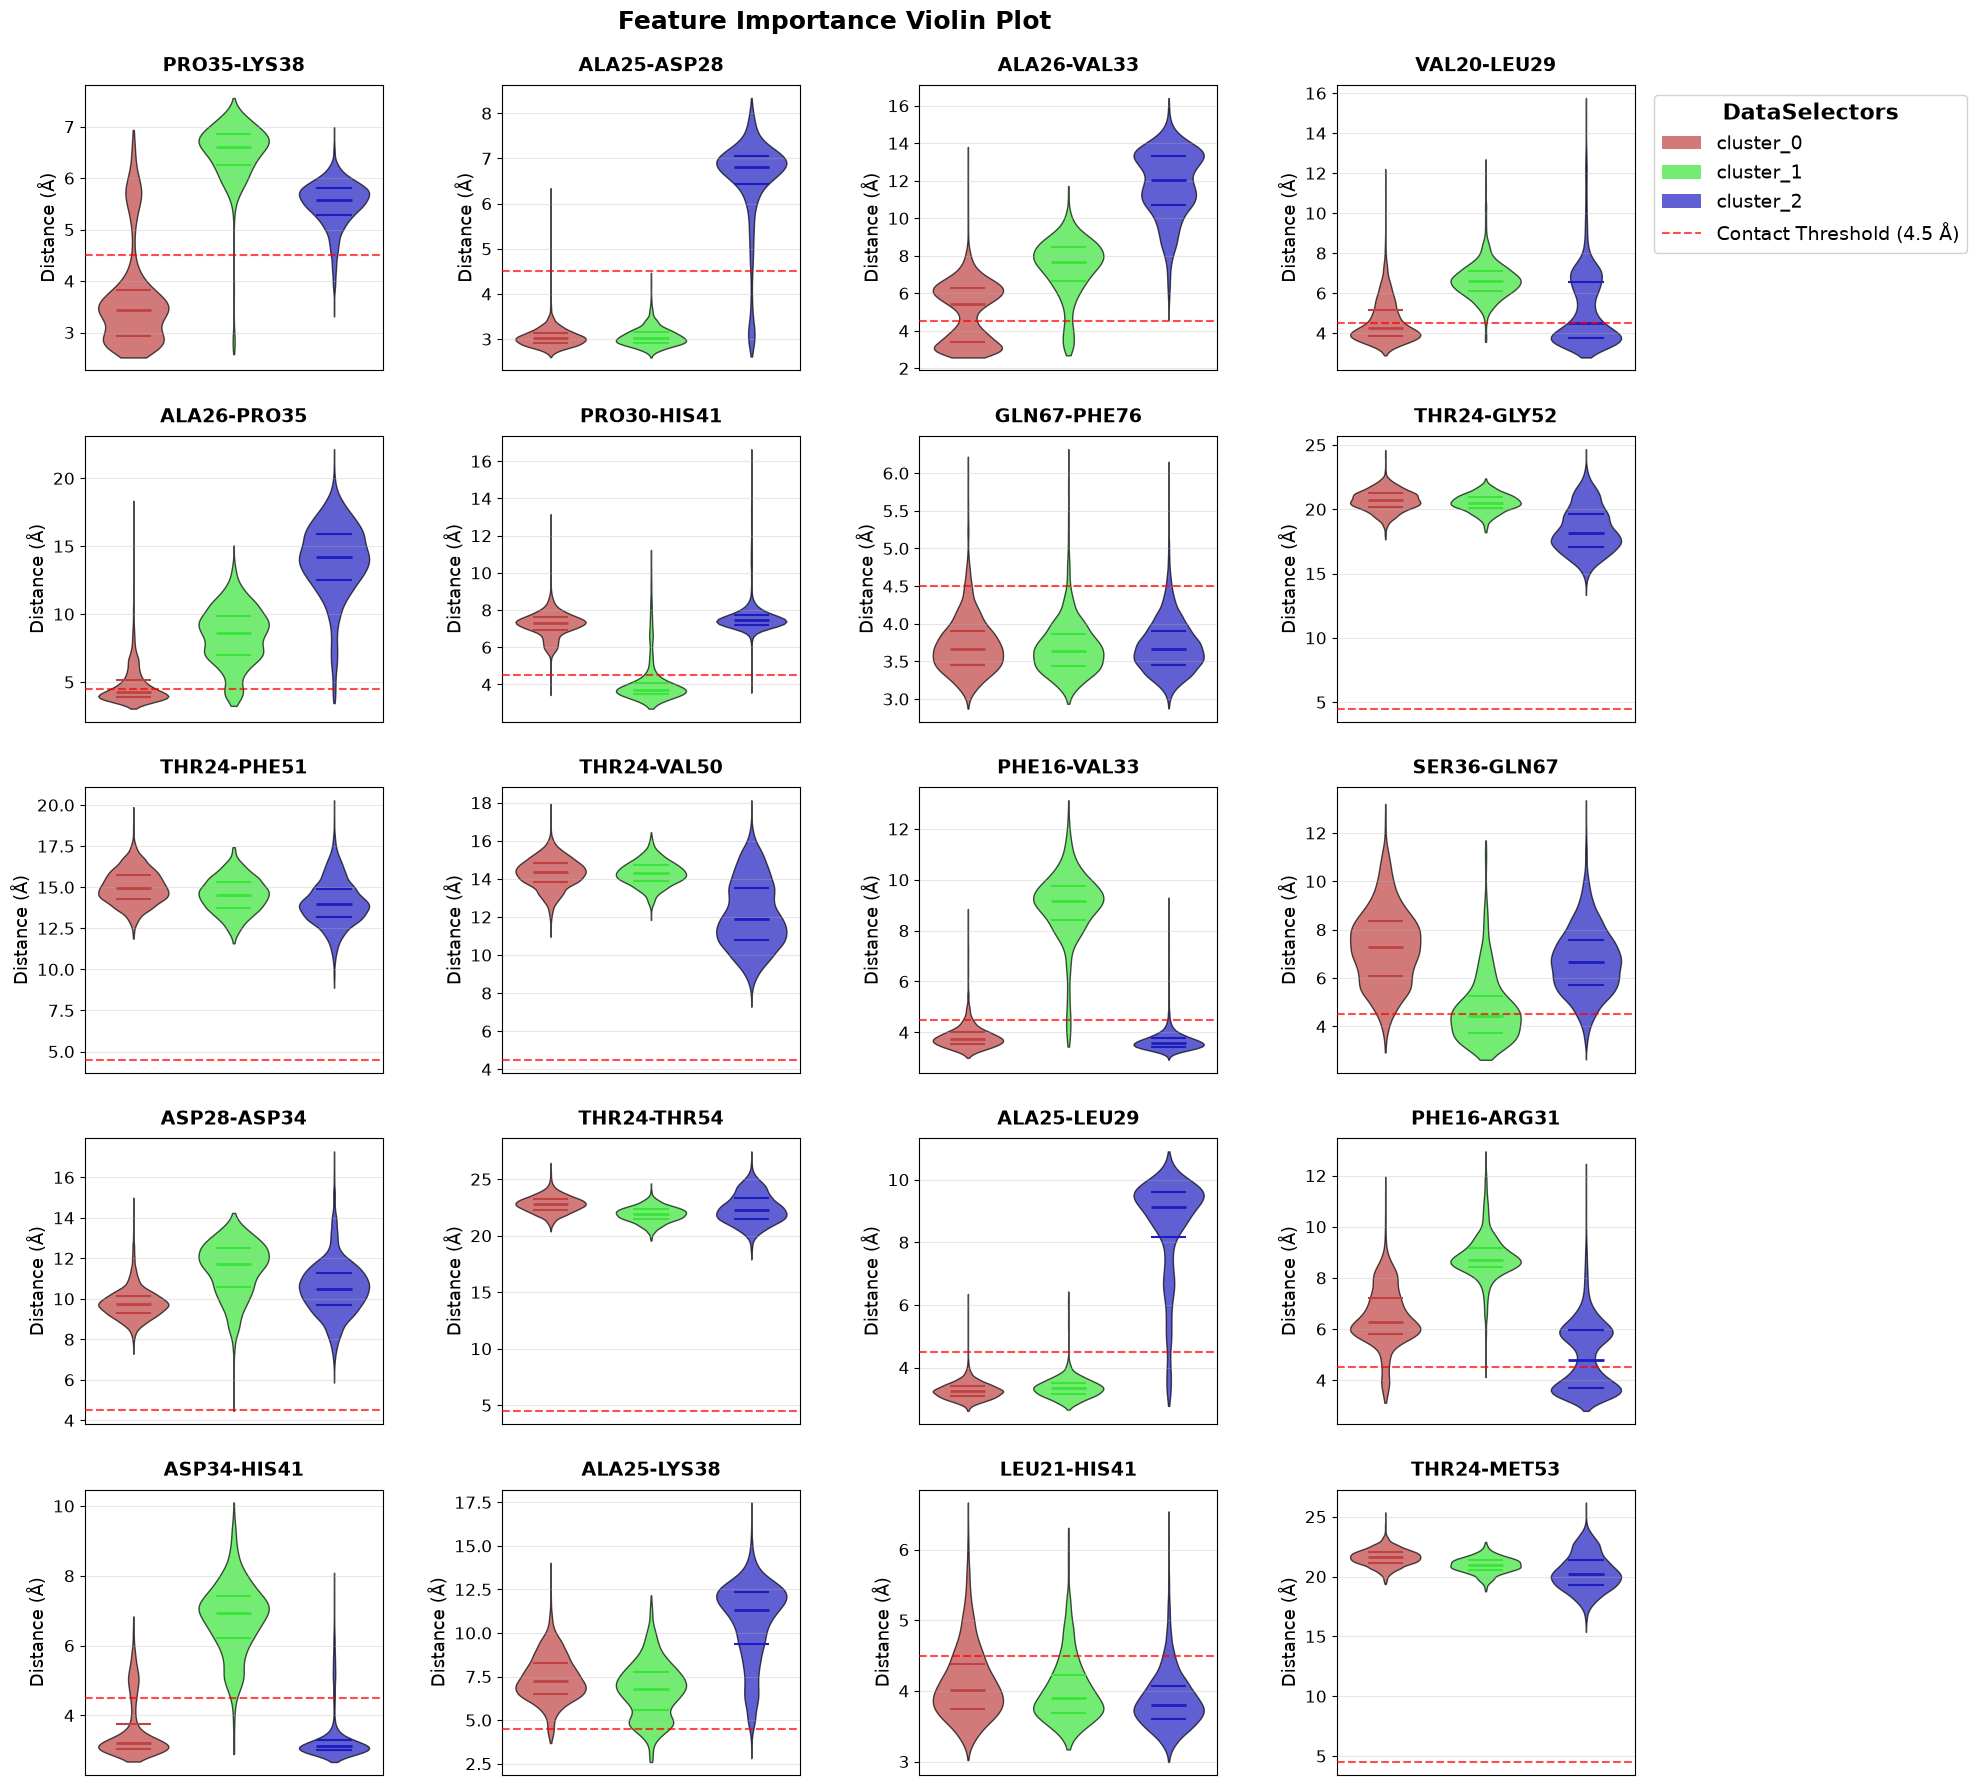

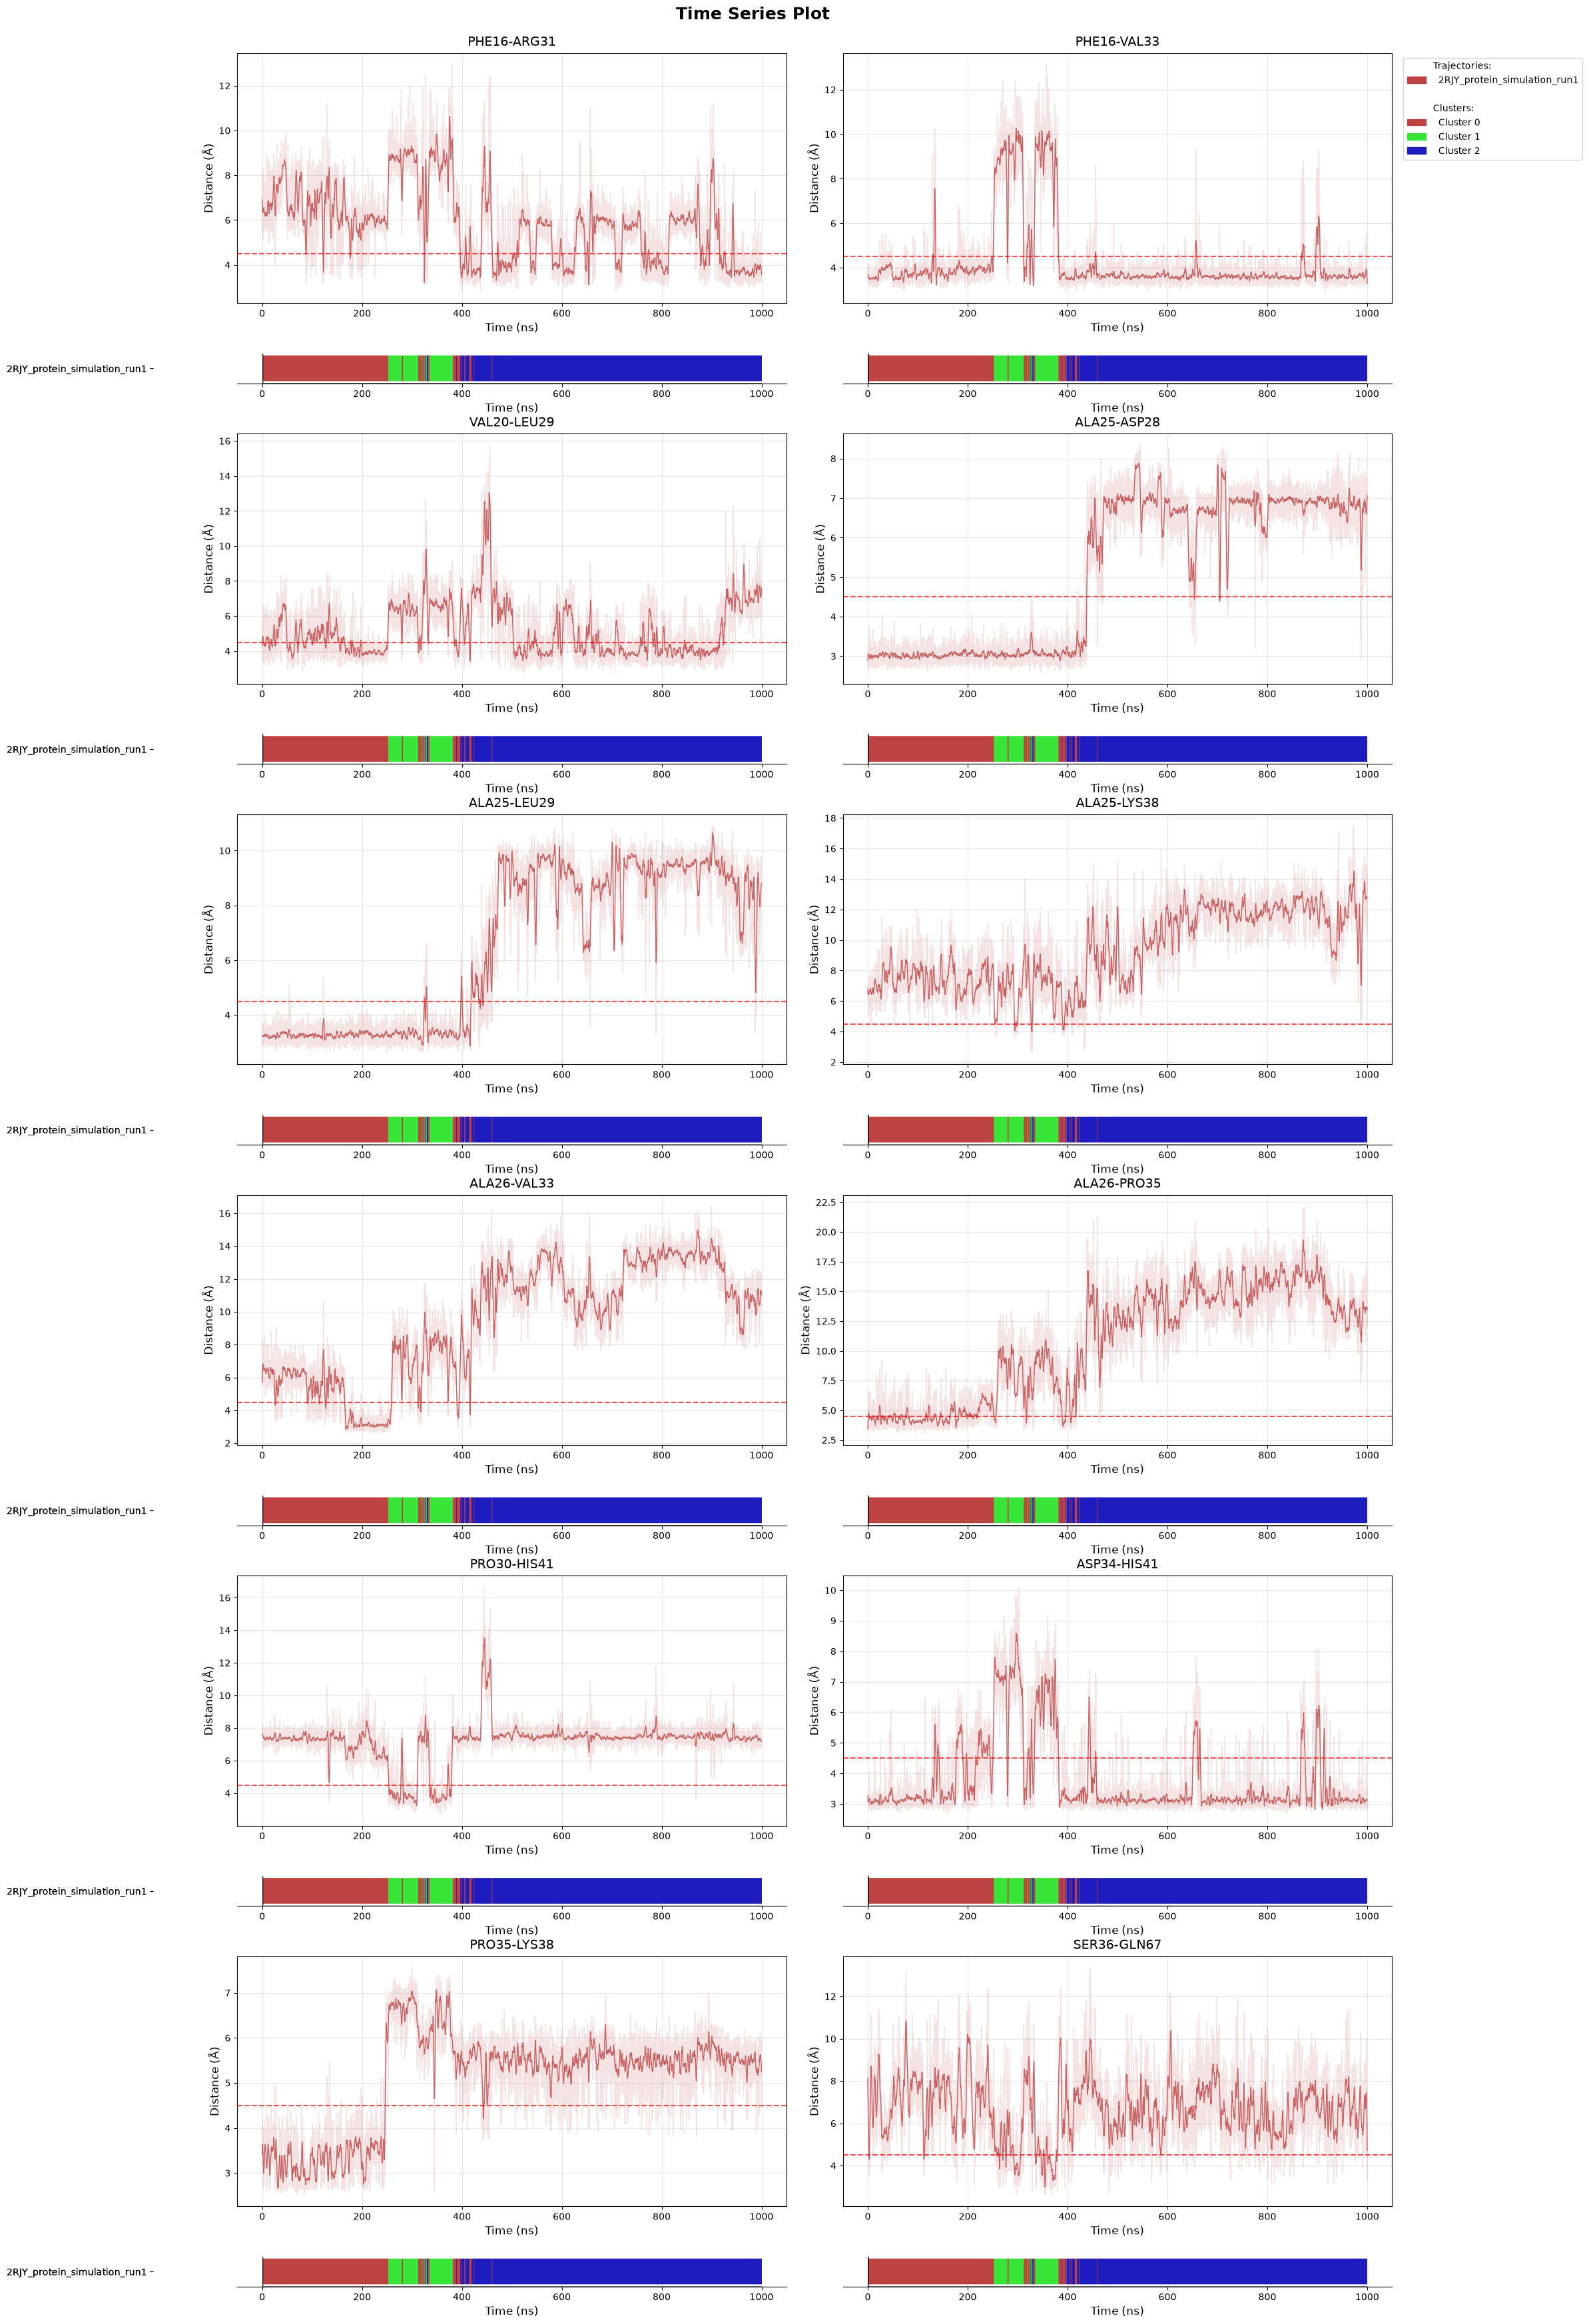

In [2]:
# Test pipeline for JSON specification with contact kernel PCA and clustering

pipeline = PipelineManager(use_memmap=True, chunk_size=1000, show_progress=False)

pipeline.trajectory.load_trajectories("../../../data/2RJY/")
pipeline.trajectory.add_labels(
        traj_selection="all"
    )
pipeline.feature.add.distances()
pipeline.feature.add.contacts(cutoff=4.5)
pipeline.feature_selector.create("contacts_only")
pipeline.feature_selector.add.contacts("contacts_only", "all")
pipeline.feature_selector.select("contacts_only")
pipeline.decomposition.add.contact_kernel_pca(
    n_components=4,
    selection_name="contacts_only", 
    decomposition_name="ContactKernelPCA",
)
pipeline.clustering.add.dpa(
    "ContactKernelPCA", 
    Z=2.5,
    cluster_name="DPA_ContactKPC",
)
fig = pipeline.plots.clustering.membership(
    clustering_name="DPA_ContactKPC",
)
fig = pipeline.plots.landscape(
    decomposition_name="ContactKernelPCA",
    dimensions=[0, 1, 2, 3],
    clustering_name="DPA_ContactKPC",
)
pipeline.data_selector.create_from_clusters(
    group_name="cluster",
    clustering_name="DPA_ContactKPC"
)

# Create one-vs-all comparison
pipeline.comparison.create_comparison(
    name="cluster_comparison",
    mode="one_vs_rest",
    feature_selector="contacts_only",
    data_selector_groups="cluster"
)
pipeline.feature_importance.add.decision_tree(
    comparison_name="cluster_comparison",
    analysis_name="feature_importance",
)
fig = pipeline.plots.feature_importance.decision_trees(
    feature_importance_name="feature_importance",
)
fig = pipeline.plots.feature_importance.violins(
    feature_importance_name="feature_importance",
)
fig = pipeline.plots.feature_importance.time_series(
    feature_importance_name="feature_importance",
    membership_per_feature=True,
    clustering_name="DPA_ContactKPC",
)
pipeline.structure_visualization.feature_importance.create_pdb_with_beta_factors(
    structure_viz_name="structure_viz",
    feature_importance_name="feature_importance",
)
pipeline.print_info()

In [3]:
# Print the log of operations in the pipeline
log = pipeline.data.log
for entry in log["operations"].values():
    print(f"Operation {entry['global_seq']}:")
    for instance, value in entry.items():
        if instance == "global_seq":
            continue
        if instance == "config":
            print(f"    {instance}:")
            for config_key, config_value in value.items():
                print(f"        {config_key}: {config_value}")
        else:
            print(f"    {instance}: {value}")

Operation 1:
    id: pipeline_init_1
    type: pipeline_init
    config:
        stride: 1
        concat: False
        selection: None
        use_memmap: True
        reuse_memmap_cache: False
        chunk_size: 1000
        dtype: <class 'numpy.float32'>
        cache_dir: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_836639877a6745eaaf857ff6aca8a3a4_20261008_132234
        max_memory_gb: 6.0
    depends_on: []
Operation 2:
    id: TrajectoryManager.load_trajectories_1
    type: TrajectoryManager.load_trajectories
    config:
        data_input: ../../../data/2RJY/
        concat: None
        stride: 1
        selection: None
        force: False
    depends_on: ['pipeline_init_1']
Operation 3:
    id: TrajectoryManager.add_labels_1
    type: TrajectoryManager.add_labels
    config:
        traj_selection: all
        fragment_definition: None
        fragment_type: None
        fragment_molecule_name: None
        consensus: False
      

## 1.1 Instances are enforced in their domains

**Adding a test instance in trajectory and a pipeline modifier**

The modifier creates a new instance in the pipeline domain instead of the trajectory domain.
-> Registry domains are enforced over the specified instance domain.

A pipeline modifier in a test instance will create a *test* instance under the pipeline domain and will not add the modifier to the *test* instance in the trajectory domain.

In [4]:
spec = SpecManager()
spec.instances.add(instance_name="test", domain="trajectory")
spec.instances.modifiers.add(
    instance_name="test",
    operation_type="pipeline_init",
    chunk_size=4,
)
spec.print_info()

SpecManager Information:
Modules:
  pipeline
    Instance: test
      Modifier: pipeline_init_1
        stride: 1
        concat: False
        selection: None
        use_memmap: True
        reuse_memmap_cache: False
        chunk_size: 4
        dtype: float32
        cache_dir: ./cache
        max_memory_gb: 6.0
      Depends on:
  trajectory
    Instance: test
  feature
  feature_selection
  decomposition
  clustering
  data_selector
  comparison
  feature_importance
  structure_visualization
  plots
  analysis
  studies


In [5]:
data_dicts = [getattr(spec.data, module) for module in spec.data.MODULES]

for i, data_dict in enumerate(data_dicts):
    print(f"{spec.data.MODULES[i]}:")
    for instance in data_dict:
        print(f"  {instance}:")
        for modifiers, mod_list in data_dict[instance].items():
            print(f"    {modifiers}:")
            for mod in mod_list:
                print(f"        {mod["mod_name"]}:")
                print(f"            Type: {mod['type']}")
                print(f"            Config:")
                for config_key, config_value in mod['config'].items():
                    print(f"                {config_key}: {config_value}")
                print(f"            Depends on: {mod['depends_on']}")
                print(f"            Depends on override: {mod['depends_on_override']}")
                print(f"            Order: {mod['order']}")


pipeline:
  test:
    modifiers:
        pipeline_init_1:
            Type: pipeline_init
            Config:
                stride: 1
                concat: False
                selection: None
                use_memmap: True
                reuse_memmap_cache: False
                chunk_size: 4
                dtype: float32
                cache_dir: ./cache
                max_memory_gb: 6.0
            Depends on: []
            Depends on override: False
            Order: 1
trajectory:
  test:
    modifiers:
feature:
feature_selection:
decomposition:
clustering:
data_selector:
comparison:
feature_importance:
structure_visualization:
plots:
analysis:
studies:


## 1.2 ``operation_type`` call different for ``pipeline_init``

**Adding a test instance in pipeline and a pipeline modifier**

The modifier only applies when the `operation_type` includes class.method_name, not only method_name. But its different for the `pipeline_init` operation.

**Open**: Why is the ``pipeline_init`` behaving differently?

In [6]:
spec = SpecManager()
spec.instances.add(
    instance_name="pipeline",
    operation_type="pipeline_init",
    stride=2,
)
spec.instances.modifiers.add(
    instance_name="pipeline",
    operation_type="PipelineManager.update_config",
    chunk_size=3,
)
spec.print_info()

SpecManager Information:
Modules:
  pipeline
    Instance: pipeline
      Modifier: pipeline_init_1
        stride: 2
        concat: False
        selection: None
        use_memmap: True
        reuse_memmap_cache: False
        chunk_size: 2000
        dtype: float32
        cache_dir: ./cache
        max_memory_gb: 6.0
      Depends on:
      Modifier: PipelineManager.update_config_1
        chunk_size: 3
        cache_dir: None
        use_memmap: None
      Depends on:
            pipeline_init_1
  trajectory
  feature
  feature_selection
  decomposition
  clustering
  data_selector
  comparison
  feature_importance
  structure_visualization
  plots
  analysis
  studies


## 1.3 Parameter validation does not check data types

**Adding a test instance for trajectory loading**

The parameters are checked if they are required, but not if they are valid, i.e if the have the correct data type or format.

In [7]:
spec = SpecManager()

spec.instances.modifiers.add(
    instance_name="traj1",
    operation_type="TrajectoryManager.load_trajectories",
    data_input="path/to/trajectory/file",
)
spec.instances.modifiers.add(
    instance_name="traj",
    operation_type="TrajectoryManager.add_trajectory",
    data_input=3,
)
spec.print_info()

SpecManager Information:
Modules:
  pipeline
  trajectory
    Instance: traj1
      Modifier: TrajectoryManager.load_trajectories_1
        data_input: path/to/trajectory/file
        concat: None
        stride: 1
        selection: None
        force: False
      Depends on:
    Instance: traj
      Modifier: TrajectoryManager.add_trajectory_1
        data_input: 3
        concat: None
        stride: 1
        selection: None
      Depends on:
            TrajectoryManager.load_trajectories_1
  feature
  feature_selection
  decomposition
  clustering
  data_selector
  comparison
  feature_importance
  structure_visualization
  plots
  analysis
  studies


## 1.4 Read from Pipeline

Reads the log from a pipeline and reconstructs graph and exports JSON.

In [8]:
pipeline_test = PipelineManager()
pipeline_test.trajectory.load_trajectories("../../../data/2RJY/")
pipeline_test.analysis.structure.rmsd.mean.to_reference()

Resource limits applied: cpu_affinity=4 cores, nice=15, io_priority=low, blas_threads=4


Loading 2RJY:   0%|          | 0/1 [00:00<?, ?it/s]

📦 Creating Zarr cache: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_f223e02b8eef454cb09d8e56fec52187_20261008_132422/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  🔍 Analyzing trajectory dimensions...


Counting frames: 6it [00:00,  6.54it/s]


  📐 Trajectory: 10001 frames × 1027 atoms
  💾 Writing trajectory data...


Processing chunks: 100%|██████████| 6/6 [00:02<00:00,  2.25it/s]


  ✅ Cache created: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_f223e02b8eef454cb09d8e56fec52187_20261008_132422/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  📊 Size: 89.1 MB

Loaded 1 systems with 1 total trajectories:
  2RJY: 1 trajectories


{'2RJY_protein_simulation_run1': array([0.        , 0.13339244, 0.15720986, ..., 0.28045228, 0.2855736 ,
        0.31079233], shape=(10001,), dtype=float32)}

In [9]:
spec_from_pipeline = SpecManager()
spec_from_pipeline.read_from_pipeline(pipeline_test)
spec_from_pipeline.print_info()

from dev_scripts.visualize_operation_graph import build_figure
print(type(spec_from_pipeline.data.graph))
build_figure(spec_from_pipeline.data.graph, title="Operation Graph").show()

spec_from_pipeline.write_json("spec_from_pipeline.json")

SpecManager Information:
Modules:
  pipeline
    Instance: pipeline_init
      Modifier: pipeline_init_1
        stride: 1
        concat: False
        selection: None
        use_memmap: True
        reuse_memmap_cache: False
        chunk_size: 2000
        dtype: <class 'numpy.float32'>
        cache_dir: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_f223e02b8eef454cb09d8e56fec52187_20261008_132422
        max_memory_gb: 6.0
      Depends on:
  trajectory
    Instance: load_trajectories
      Modifier: TrajectoryManager.load_trajectories_1
        data_input: ../../../data/2RJY/
        concat: None
        stride: 1
        selection: None
        force: False
      Depends on:
            pipeline_init_1
  feature
  feature_selection
  decomposition
  clustering
  data_selector
  comparison
  feature_importance
  structure_visualization
  plots
  analysis
    Instance: to_reference
      Modifier: RMSDMeanService.to_reference_1
        re

## 1.5 Manual adding modifiers

Manual adding of modifiers to a SpecData object is tedious, but works. The Comparison of a SpecData object from a runtime pipeline versus one constructed manually is consistent.
Single modifiers may differ in their order, but as long as their dependency is preserved the overall structure remains valid.

In [10]:
spec_manual = SpecManager()
spec_manual.instances.add(
    instance_name="start",
    operation_type="pipeline_init",
    stride=2,
)
spec_manual.instances.add(
    instance_name="trajs",
    operation_type="TrajectoryManager.load_trajectories",
    data_input="../../../data/2RJY/",
)
spec_manual.instances.add(
    instance_name="trajs",
    operation_type="TrajectoryManager.add_labels",
    traj_selection="all", nomenclature_kwargs={},
)
spec_manual.instances.add(operation_type="FeatureAddService.distances")
spec_manual.instances.add(
    operation_type="FeatureAddService.contacts",
    cutoff=4.5,
)
spec_manual.instances.add(
    operation_type="FeatureSelectorManager.create",
    name="contacts_only",
)
spec_manual.instances.add(
    operation_type="ContactsSelectionService.contacts",
    selector_name="contacts_only",
    selection="all",
)
spec_manual.instances.add(
    operation_type="FeatureSelectorManager.select",
    name="contacts_only",
)
spec_manual.instances.add(
    operation_type="DecompositionAddService.contact_kernel_pca",
    n_components=4,
    selection_name="contacts_only", 
    decomposition_name="ContactKernelPCA",
)
spec_manual.instances.add(
    operation_type="DPAAddService.dpa",
    selection_name="ContactKernelPCA",
    Z=2.5,
    cluster_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="ClusteringFacade.membership",
    clustering_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="PlotsManager.landscape",
    decomposition_name="ContactKernelPCA",
    dimensions=[0, 1, 2, 3],
    clustering_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="DataSelectorManager.create_from_clusters",
    group_name="cluster",
    clustering_name="DPA_ContactKPC"
)
spec_manual.instances.add(
    operation_type="ComparisonManager.create_comparison",
    name="cluster_comparison",
    mode="one_vs_rest",
    feature_selector="contacts_only",
    data_selector_groups="cluster"
)
spec_manual.instances.add(
    operation_type="FeatureImportanceAddService.decision_tree",
    comparison_name="cluster_comparison",
    analysis_name="feature_importance",
)
spec_manual.instances.add(
    operation_type="FeatureImportanceFacade.decision_trees",
    feature_importance_name="feature_importance",
)
spec_manual.instances.add(
    operation_type="FeatureImportanceFacade.violins",
    feature_importance_name="feature_importance",
)
spec_manual.instances.add(
    operation_type="FeatureImportanceFacade.time_series",
    feature_importance_name="feature_importance",
    membership_per_feature=True,
    clustering_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="StructureVizFeatureImportanceService.create_pdb_with_beta_factors",
    structure_viz_name="structure_viz",
    feature_importance_name="feature_importance",
)


'StructureVizFeatureImportanceService.create_pdb_with_beta_factors_1'

In [11]:
spec_manual.write_json("spec_manual.json")
new_spec = SpecManager()
new_spec.read_json("spec_manual.json")
new_spec.write_json("new_spec_manual.json")

manual_mods = spec_manual.data.get_all_modifiers()
new_manual_mods = new_spec.data.get_all_modifiers()
print(manual_mods == new_manual_mods)

True


In [12]:
spec_from_pipeline = SpecManager()
spec_from_pipeline.read_from_pipeline(pipeline)

In [13]:
SpecValidatorHelper.compare_specs(spec_from_pipeline.data, spec_manual.data)

{'equal': False,
 'domains': {'pipeline': {'missing_modifiers': [{'mod_name': 'pipeline_init_1',
     'type': 'pipeline_init',
     'config': {'stride': 1,
      'concat': False,
      'selection': None,
      'use_memmap': True,
      'reuse_memmap_cache': False,
      'chunk_size': 1000,
      'dtype': numpy.float32,
      'cache_dir': '/home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_836639877a6745eaaf857ff6aca8a3a4_20261008_132234',
      'max_memory_gb': 6.0},
     'depends_on': [],
     'depends_on_override': False,
     'order': 1}],
   'extra_modifiers': [{'mod_name': 'pipeline_init_1',
     'type': 'pipeline_init',
     'config': {'stride': 2,
      'concat': False,
      'selection': None,
      'use_memmap': True,
      'reuse_memmap_cache': False,
      'chunk_size': 2000,
      'dtype': 'float32',
      'cache_dir': './cache',
      'max_memory_gb': 6.0},
     'depends_on': [],
     'depends_on_override': False,
     'order': 1}]}}}

## 1.6 CRUD tests

**Base spec for the CRUD tests**

The following tests change a copy of one base spec. Instance ``sel_a`` holds a chain of three modifiers (``create`` -> ``contacts`` -> ``select``), ``sel_b`` holds a single ``create`` call.

The base spec is not meant to reflect a normal pipeline workflow, but rather to demonstrate the different dependencies.

In [14]:
spec_base = SpecManager()
spec_base.instances.add(
    instance_name="sel_a",
    operation_type="FeatureSelectorManager.create",
    name="sel_a",
)
spec_base.instances.add(
    operation_type="ContactsSelectionService.contacts",
    selector_name="sel_a",
    selection="all",
)
spec_base.instances.add(
    operation_type="FeatureSelectorManager.select",
    name="sel_a",
)
spec_base.instances.add(
    instance_name="sel_b",
    operation_type="FeatureSelectorManager.create",
    name="sel_b",
)
spec_base.write_json("spec_base.json")
spec_base.print_info()
build_figure(spec_base.data.graph, title="Base spec").show()

SpecManager Information:
Modules:
  pipeline
  trajectory
  feature
  feature_selection
    Instance: sel_a
      Modifier: FeatureSelectorManager.create_1
        name: sel_a
      Depends on:
      Modifier: ContactsSelectionService.contacts_1
        selector_name: sel_a
        selection: all
        use_reduced: False
        common_denominator: True
        traj_selection: all
        require_all_partners: False
      Depends on:
            FeatureSelectorManager.create_1
      Modifier: FeatureSelectorManager.select_1
        name: sel_a
        reference_traj: None
      Depends on:
            ContactsSelectionService.contacts_1
    Instance: sel_b
      Modifier: FeatureSelectorManager.create_2
        name: sel_b
      Depends on:
  decomposition
  clustering
  data_selector
  comparison
  feature_importance
  structure_visualization
  plots
  analysis
  studies


### 1.6.1 Get, list and update modifiers

**Reading and updating modifiers by ``domain``, ``instance_name`` and ``modifier_name``**

Only ``add`` needs an ``operation_type``. All other modifier operations address the modifier by ``domain``, ``instance_name`` and ``modifier_name``.

``instances.update`` changes the creating call, i.e. the first modifier of the instance.

In [15]:
spec = copy.deepcopy(spec_base)
mods = spec.instances.modifiers
build_figure(spec.data.graph, title="2.6.1 before").show()

# update the config of a single modifier
mods.update("feature_selection", "sel_a", "ContactsSelectionService.contacts_1", selection="frequent")
print(mods.get("feature_selection", "sel_a", "ContactsSelectionService.contacts_1")["config"]["selection"])
print([m["mod_name"] for m in mods.list("feature_selection", "sel_a")])

# update the creating call of an instance
spec.instances.update("feature_selection", "sel_b", name="sel_b_renamed")
print(spec.data.feature_selection["sel_b"]["modifiers"][0]["config"]["name"])

# update with depends_on=None leaves the dependencies unchanged
print(mods.get("feature_selection", "sel_a", "ContactsSelectionService.contacts_1")["depends_on"])
build_figure(spec.data.graph, title="2.6.1 after (same edges, new config in the hover text)").show()


frequent
['FeatureSelectorManager.create_1', 'ContactsSelectionService.contacts_1', 'FeatureSelectorManager.select_1']
sel_b_renamed
['FeatureSelectorManager.create_1']


### 1.6.2 Override ``depends_on``

**Setting ``depends_on`` explicitly**

An explicit ``depends_on`` sets ``depends_on_override`` and is not recomputed by later mutations. ``set_depends_on`` with ``None`` hands the modifier back to the automatic resolution. ``update`` with ``depends_on=None`` leaves the dependencies unchanged.

In [16]:
spec = copy.deepcopy(spec_base)
mods = spec.instances.modifiers
build_figure(spec.data.graph, title="2.6.2 before").show()

# explicit override on an existing modifier
mods.set_depends_on("feature_selection", "sel_a", "FeatureSelectorManager.select_1", ["FeatureSelectorManager.create_2"])
print([(m["mod_name"], m["depends_on"], m["depends_on_override"]) for m in spec.data.feature_selection["sel_a"]["modifiers"]])
build_figure(spec.data.graph, title="2.6.2 after override (select_1 depends on create_2)").show()

# an unrelated mutation does not touch the override
mods.update("feature_selection", "sel_a", "ContactsSelectionService.contacts_1", selection="frequent")
print([(m["mod_name"], m["depends_on"], m["depends_on_override"]) for m in spec.data.feature_selection["sel_a"]["modifiers"]])
build_figure(spec.data.graph, title="2.6.2 after unrelated update (override unchanged)").show()

# None hands the modifier back to the automatic resolution
mods.set_depends_on("feature_selection", "sel_a", "FeatureSelectorManager.select_1", None)
print([(m["mod_name"], m["depends_on"], m["depends_on_override"]) for m in spec.data.feature_selection["sel_a"]["modifiers"]])
build_figure(spec.data.graph, title="2.6.2 after reset to automatic resolution").show()

# explicit override while adding, an empty list is an override too
spec.instances.add(operation_type="FeatureSelectorManager.select", name="sel_b", depends_on=[])
print([(m["mod_name"], m["depends_on"], m["depends_on_override"]) for m in spec.data.feature_selection["sel_b"]["modifiers"]])
build_figure(spec.data.graph, title="2.6.2 after add with depends_on=[] (no incoming edge)").show()


[('FeatureSelectorManager.create_1', [], False), ('ContactsSelectionService.contacts_1', ['FeatureSelectorManager.create_1'], False), ('FeatureSelectorManager.select_1', ['FeatureSelectorManager.create_2'], True)]


[('FeatureSelectorManager.create_1', [], False), ('ContactsSelectionService.contacts_1', ['FeatureSelectorManager.create_1'], False), ('FeatureSelectorManager.select_1', ['FeatureSelectorManager.create_2'], True)]


[('FeatureSelectorManager.create_1', [], False), ('ContactsSelectionService.contacts_1', ['FeatureSelectorManager.create_1'], False), ('FeatureSelectorManager.select_1', ['ContactsSelectionService.contacts_1'], False)]


[('FeatureSelectorManager.create_2', [], False), ('FeatureSelectorManager.select_2', [], True)]


### 1.6.3 Remove a modifier

**Removing a modifier that other modifiers depend on**

Automatically resolved ``depends_on`` are recomputed after the removal: ``select`` falls back to the ``create`` call.

An explicitly set ``depends_on`` is frozen and still points to the removed modifier.

In [17]:
spec = copy.deepcopy(spec_base)
mods = spec.instances.modifiers
build_figure(spec.data.graph, title="2.6.3 automatic depends_on, before").show()
mods.remove("feature_selection", "sel_a", "ContactsSelectionService.contacts_1")
print([(m["mod_name"], m["depends_on"], m["depends_on_override"]) for m in spec.data.feature_selection["sel_a"]["modifiers"]])
build_figure(spec.data.graph, title="2.6.3 automatic depends_on, after removing contacts_1").show()

# an explicit override is not touched by the resync and stays dangling
spec = copy.deepcopy(spec_base)
mods = spec.instances.modifiers
mods.set_depends_on("feature_selection", "sel_a", "FeatureSelectorManager.select_1", ["ContactsSelectionService.contacts_1"])
build_figure(spec.data.graph, title="2.6.3 explicit depends_on, before").show()
mods.remove("feature_selection", "sel_a", "ContactsSelectionService.contacts_1")
print([(m["mod_name"], m["depends_on"], m["depends_on_override"]) for m in spec.data.feature_selection["sel_a"]["modifiers"]])
build_figure(spec.data.graph, title="2.6.3 explicit depends_on, after removing contacts_1 (no edge to the removed node)").show()


[('FeatureSelectorManager.create_1', [], False), ('FeatureSelectorManager.select_1', ['FeatureSelectorManager.create_1'], False)]


[('FeatureSelectorManager.create_1', [], False), ('FeatureSelectorManager.select_1', ['ContactsSelectionService.contacts_1'], True)]


### 1.6.4 Reorder a modifier

**Moving a modifier inside its instance**

``new_position`` is the index inside the modifier list of the instance. All modifiers get a new ``order`` and the automatically resolved ``depends_on`` are recomputed against the new sequence.

Moving ``select`` in front of the contacts selection makes the contacts selection depend on ``select`` (it writes the same selector), while ``select`` falls back to the ``create`` call.

In [18]:
spec = copy.deepcopy(spec_base)
mods = spec.instances.modifiers
build_figure(spec.data.graph, title="2.6.4 move select before contacts, before").show()
mods.reorder("feature_selection", "sel_a", "FeatureSelectorManager.select_1", 1)
for m in spec.data.feature_selection["sel_a"]["modifiers"]:
    print(m["order"], m["mod_name"], m["depends_on"])
build_figure(spec.data.graph, title="2.6.4 move select before contacts, after").show()

# moving the contacts selection in front of the create call: no selector exists yet
spec = copy.deepcopy(spec_base)
mods = spec.instances.modifiers
build_figure(spec.data.graph, title="2.6.4 move contacts to position 0, before").show()
mods.reorder("feature_selection", "sel_a", "ContactsSelectionService.contacts_1", 0)
for m in spec.data.feature_selection["sel_a"]["modifiers"]:
    print(m["order"], m["mod_name"], m["depends_on"])
build_figure(spec.data.graph, title="2.6.4 move contacts to position 0, after").show()


1 FeatureSelectorManager.create_1 []
2 FeatureSelectorManager.select_1 ['FeatureSelectorManager.create_1']
3 ContactsSelectionService.contacts_1 ['FeatureSelectorManager.select_1']


1 ContactsSelectionService.contacts_1 []
2 FeatureSelectorManager.create_1 []
3 FeatureSelectorManager.select_1 ['FeatureSelectorManager.create_1']


### 1.6.5 Remove an instance

**Removing a whole instance and removing the last modifier of an instance**

``instances.remove`` is addressed by ``domain`` and ``instance_name`` only. Removing the last modifier of an instance removes the (then empty) instance as well.

In [19]:
spec = copy.deepcopy(spec_base)
build_figure(spec.data.graph, title="2.6.5 remove instance, before").show()
spec.instances.remove("feature_selection", "sel_b")
print(list(spec.data.feature_selection))
build_figure(spec.data.graph, title="2.6.5 remove instance, after removing sel_b").show()

# removing the last modifier of an instance removes the instance as well
spec = copy.deepcopy(spec_base)
build_figure(spec.data.graph, title="2.6.5 remove last modifier, before").show()
spec.instances.modifiers.remove("feature_selection", "sel_b", "FeatureSelectorManager.create_2")
print(list(spec.data.feature_selection))
build_figure(spec.data.graph, title="2.6.5 remove last modifier, after").show()


['sel_a']


['sel_a']


### 1.6.6 Instance without a modifier

**Adding an instance by domain only**

An instance can be created without a modifier. It stays in the spec as ``{"modifiers": []}`` and later modifiers are appended to it.

In [20]:
spec = copy.deepcopy(spec_base)
build_figure(spec.data.graph, title="2.6.6 before").show()
spec.instances.add(instance_name="empty", domain="feature_selection")
print(spec.data.feature_selection["empty"])
build_figure(spec.data.graph, title="2.6.6 after adding the empty instance (graph unchanged)").show()

# a later modifier is appended to the existing, empty instance
spec.instances.add(
    instance_name="empty",
    operation_type="FeatureSelectorManager.create",
    name="empty",
)
spec.print_info()
build_figure(spec.data.graph, title="2.6.6 after adding a modifier to the empty instance (new node)").show()


{'modifiers': []}


SpecManager Information:
Modules:
  pipeline
  trajectory
  feature
  feature_selection
    Instance: sel_a
      Modifier: FeatureSelectorManager.create_1
        name: sel_a
      Depends on:
      Modifier: ContactsSelectionService.contacts_1
        selector_name: sel_a
        selection: all
        use_reduced: False
        common_denominator: True
        traj_selection: all
        require_all_partners: False
      Depends on:
            FeatureSelectorManager.create_1
      Modifier: FeatureSelectorManager.select_1
        name: sel_a
        reference_traj: None
      Depends on:
            ContactsSelectionService.contacts_1
    Instance: sel_b
      Modifier: FeatureSelectorManager.create_2
        name: sel_b
      Depends on:
    Instance: empty
      Modifier: FeatureSelectorManager.create_3
        name: empty
      Depends on:
  decomposition
  clustering
  data_selector
  comparison
  feature_importance
  structure_visualization
  plots
  analysis
  studies


# 2. Replay: SpecData -> new pipeline

`SpecManager.new_pipeline()` replays every modifier of a spec (in dependency order) as real manager/service calls on a freshly built `PipelineManager`, using each registered operation's `access_path` (see `mdxplain/utils/operation_registry.json` and `dev_scripts/populate_access_paths.py`). Return values are collected under each modifier's `mod_name` in `spec.data.replay_results`.

Uses `spec_from_pipeline` from section 2.4, built from `pipeline_test`'s real log.

## 2.1 Replay: pipeline -> SpecData -> new pipeline

In [21]:
replay_source_pipeline = PipelineManager(show_progress=False)
replay_source_pipeline.trajectory.load_trajectories("../../../data/2RJY/")
replay_source_pipeline.analysis.structure.rmsd.mean.to_reference()

replay_spec = SpecManager()
replay_spec.read_from_pipeline(replay_source_pipeline)
replayed_pipeline = replay_spec.new_pipeline()

orig_types = {op["type"] for op in replay_source_pipeline.data.log["operations"].values()}
replayed_types = {op["type"] for op in replayed_pipeline.data.log["operations"].values()}

print("Operation types match:", orig_types == replayed_types)
print("Replay results:", list(replay_spec.data.replay_results.keys()))


📦 Creating Zarr cache: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_910edcae98404d2a9c62f46d241bc4ee_20261008_132432/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  🔍 Analyzing trajectory dimensions...
  📐 Trajectory: 10001 frames × 1027 atoms
  💾 Writing trajectory data...
  ✅ Cache created: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_910edcae98404d2a9c62f46d241bc4ee_20261008_132432/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  📊 Size: 89.1 MB

Loaded 1 systems with 1 total trajectories:
  2RJY: 1 trajectories
Resource limits applied: cpu_affinity=2 cores, nice=15, io_priority=low, blas_threads=2


Loading 2RJY:   0%|          | 0/1 [00:00<?, ?it/s]

Deleting existing Zarr cache at: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_910edcae98404d2a9c62f46d241bc4ee_20261008_132432/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
📦 Creating Zarr cache: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_910edcae98404d2a9c62f46d241bc4ee_20261008_132432/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  🔍 Analyzing trajectory dimensions...


Counting frames: 6it [00:00,  6.19it/s]


  📐 Trajectory: 10001 frames × 1027 atoms
  💾 Writing trajectory data...


Processing chunks: 100%|██████████| 6/6 [00:02<00:00,  2.35it/s]


  ✅ Cache created: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_910edcae98404d2a9c62f46d241bc4ee_20261008_132432/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  📊 Size: 89.1 MB

Loaded 1 systems with 1 total trajectories:
  2RJY: 1 trajectories
Operation types match: True
Replay results: ['pipeline_init_1', 'TrajectoryManager.load_trajectories_1', 'RMSDMeanService.to_reference_1']


## 2.2 Replay: SpecData -> new pipeline -> new SpecData

In [22]:
# Manual specification of a pipeline using SpecManager

spec_manual = SpecManager()
spec_manual.instances.add(
    instance_name="start",
    operation_type="pipeline_init",
    stride=2,
)
spec_manual.instances.add(
    instance_name="trajs",
    operation_type="TrajectoryManager.load_trajectories",
    data_input="../../../data/2RJY/",
)
spec_manual.instances.add(
    instance_name="trajs",
    operation_type="TrajectoryManager.add_labels",
    traj_selection="all", nomenclature_kwargs={},
)
spec_manual.instances.add(operation_type="FeatureAddService.distances")
spec_manual.instances.add(
    operation_type="FeatureAddService.contacts",
    cutoff=4.5,
)
spec_manual.instances.add(
    operation_type="FeatureSelectorManager.create",
    name="contacts_only",
)
spec_manual.instances.add(
    operation_type="ContactsSelectionService.contacts",
    selector_name="contacts_only",
    selection="all",
)
spec_manual.instances.add(
    operation_type="FeatureSelectorManager.select",
    name="contacts_only",
)
spec_manual.instances.add(
    operation_type="DecompositionAddService.contact_kernel_pca",
    n_components=4,
    selection_name="contacts_only", 
    decomposition_name="ContactKernelPCA",
)
spec_manual.instances.add(
    operation_type="DPAAddService.dpa",
    selection_name="ContactKernelPCA",
    Z=2.5,
    cluster_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="ClusteringFacade.membership",
    clustering_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="PlotsManager.landscape",
    decomposition_name="ContactKernelPCA",
    dimensions=[0, 1, 2, 3],
    clustering_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="DataSelectorManager.create_from_clusters",
    group_name="cluster",
    clustering_name="DPA_ContactKPC"
)
spec_manual.instances.add(
    operation_type="ComparisonManager.create_comparison",
    name="cluster_comparison",
    mode="one_vs_rest",
    feature_selector="contacts_only",
    data_selector_groups="cluster"
)
spec_manual.instances.add(
    operation_type="FeatureImportanceAddService.decision_tree",
    comparison_name="cluster_comparison",
    analysis_name="feature_importance",
)
spec_manual.instances.add(
    operation_type="FeatureImportanceFacade.decision_trees",
    feature_importance_name="feature_importance",
)
spec_manual.instances.add(
    operation_type="FeatureImportanceFacade.violins",
    feature_importance_name="feature_importance",
)
spec_manual.instances.add(
    operation_type="FeatureImportanceFacade.time_series",
    feature_importance_name="feature_importance",
    membership_per_feature=True,
    clustering_name="DPA_ContactKPC",
)
spec_manual.instances.add(
    operation_type="StructureVizFeatureImportanceService.create_pdb_with_beta_factors",
    structure_viz_name="structure_viz",
    feature_importance_name="feature_importance",
)


'StructureVizFeatureImportanceService.create_pdb_with_beta_factors_1'

Resource limits applied: cpu_affinity=2 cores, nice=15, io_priority=low, blas_threads=2
Created feature selector: 'contacts_only'


Loading 2RJY:   0%|          | 0/1 [00:00<?, ?it/s]

📦 Creating Zarr cache: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_dd39612ec7ad4648875388ba7cfecac2_20261008_132443/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  🔍 Analyzing trajectory dimensions...


Counting frames: 6it [00:01,  5.76it/s]


  📐 Trajectory: 10001 frames × 1027 atoms
  💾 Writing trajectory data...


...

Added to selector 'contacts_only': contacts -> 'all' (use_reduced=False, common_denominator=True, traj_selection=all, require_all_partners=False)
Applied feature selector 'contacts_only' with reference trajectory 0 successfully


Centering kernel matrix: 100%|██████████| 6/6 [00:03<00:00,  1.89chunks/s]


Starting eigendecomposition for 4 components...
Eigendecomposition completed after 21 matrix-vector products
Decomposition 'contact_kernel_pca' with name 'ContactKernelPCA' for selection 'contacts_only' computed successfully. Data reduced from (10001, 1953) to (10001, 4).
Clustering 'DPA_ContactKPC' completed successfully.
Found 3 clusters for 10001 frames.


Creating frame selection: 100%|██████████| 6/6 [00:00<00:00, 50.33chunks/s]


ℹ️  depth=3 ≤ 4: Automatically using Grid mode
Loading time data...


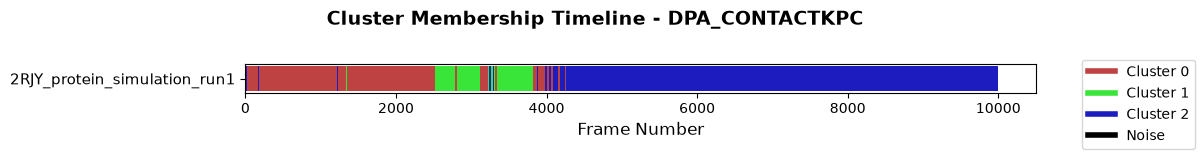

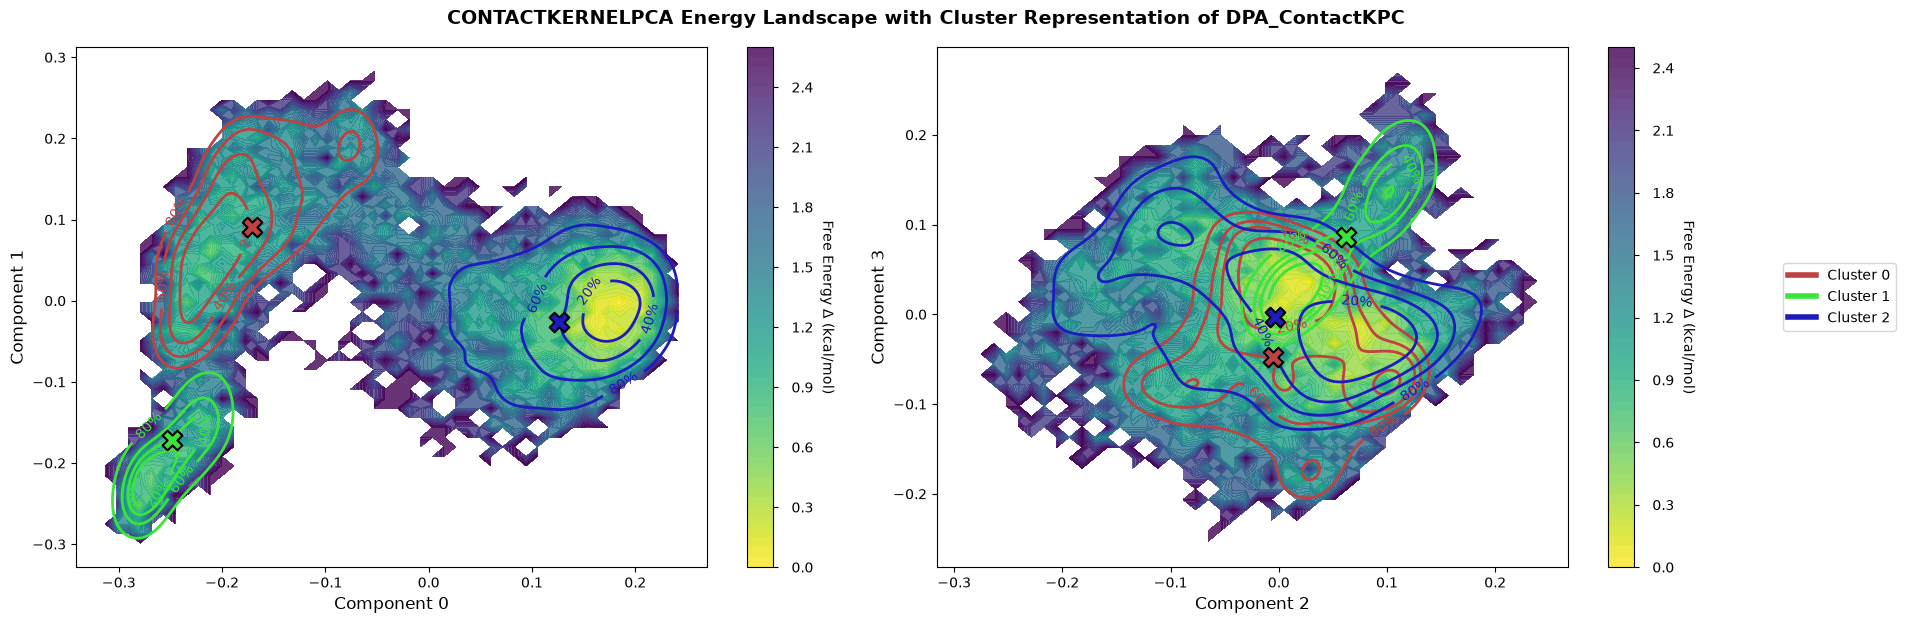

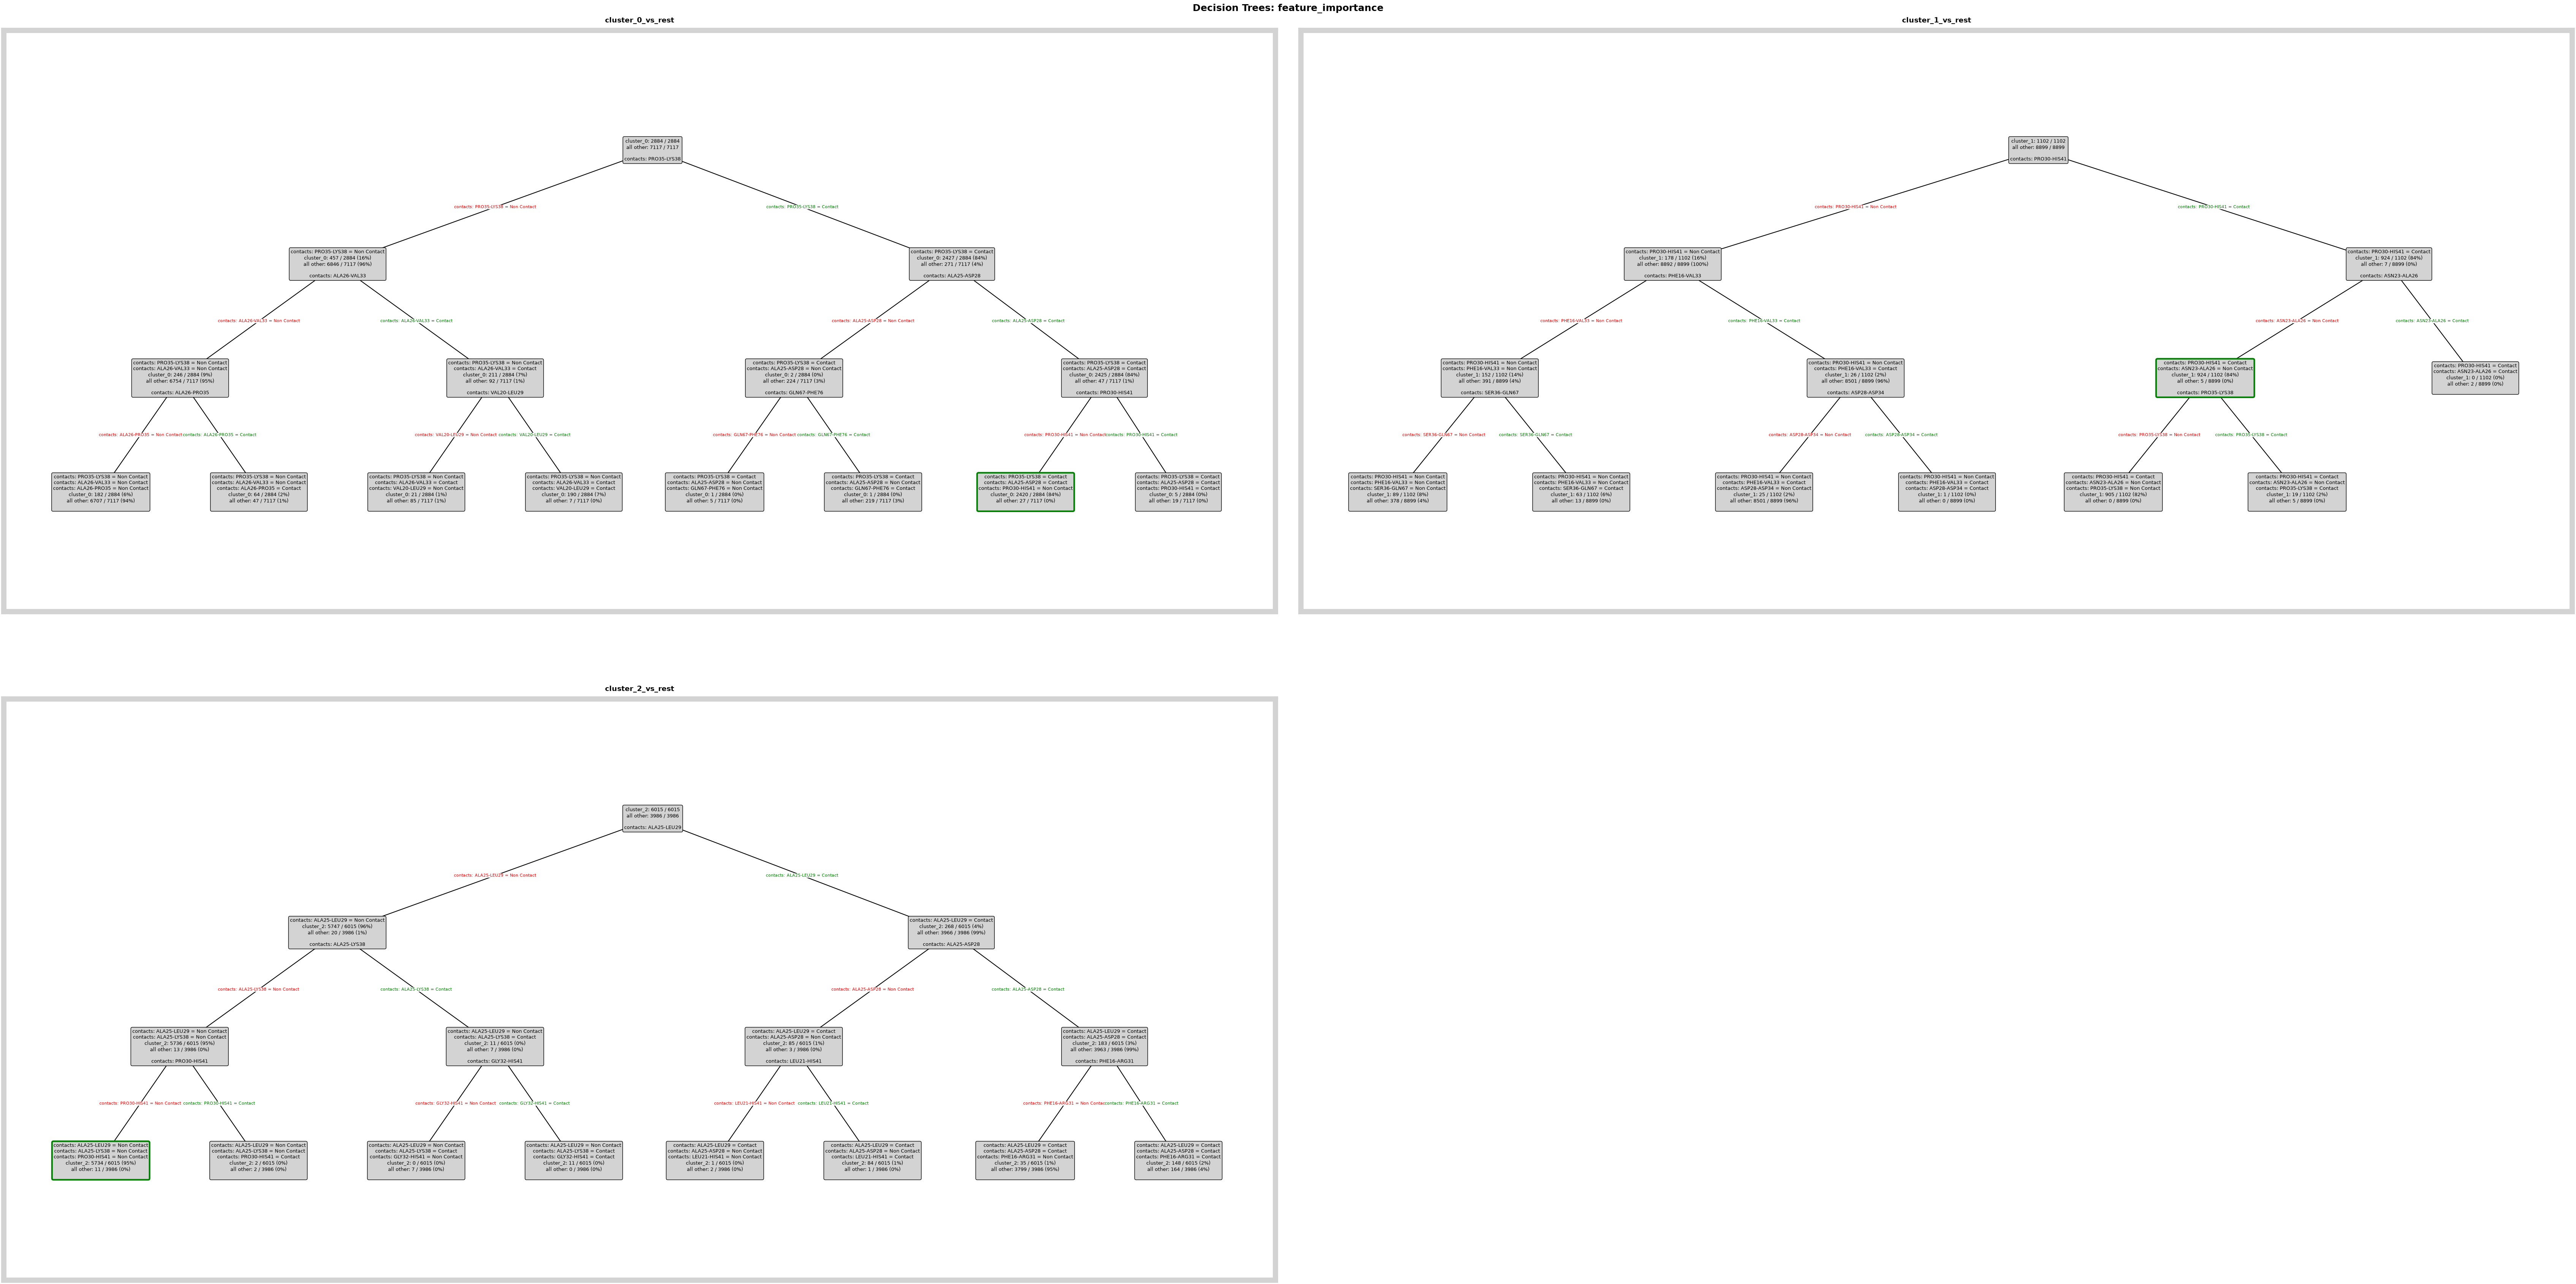

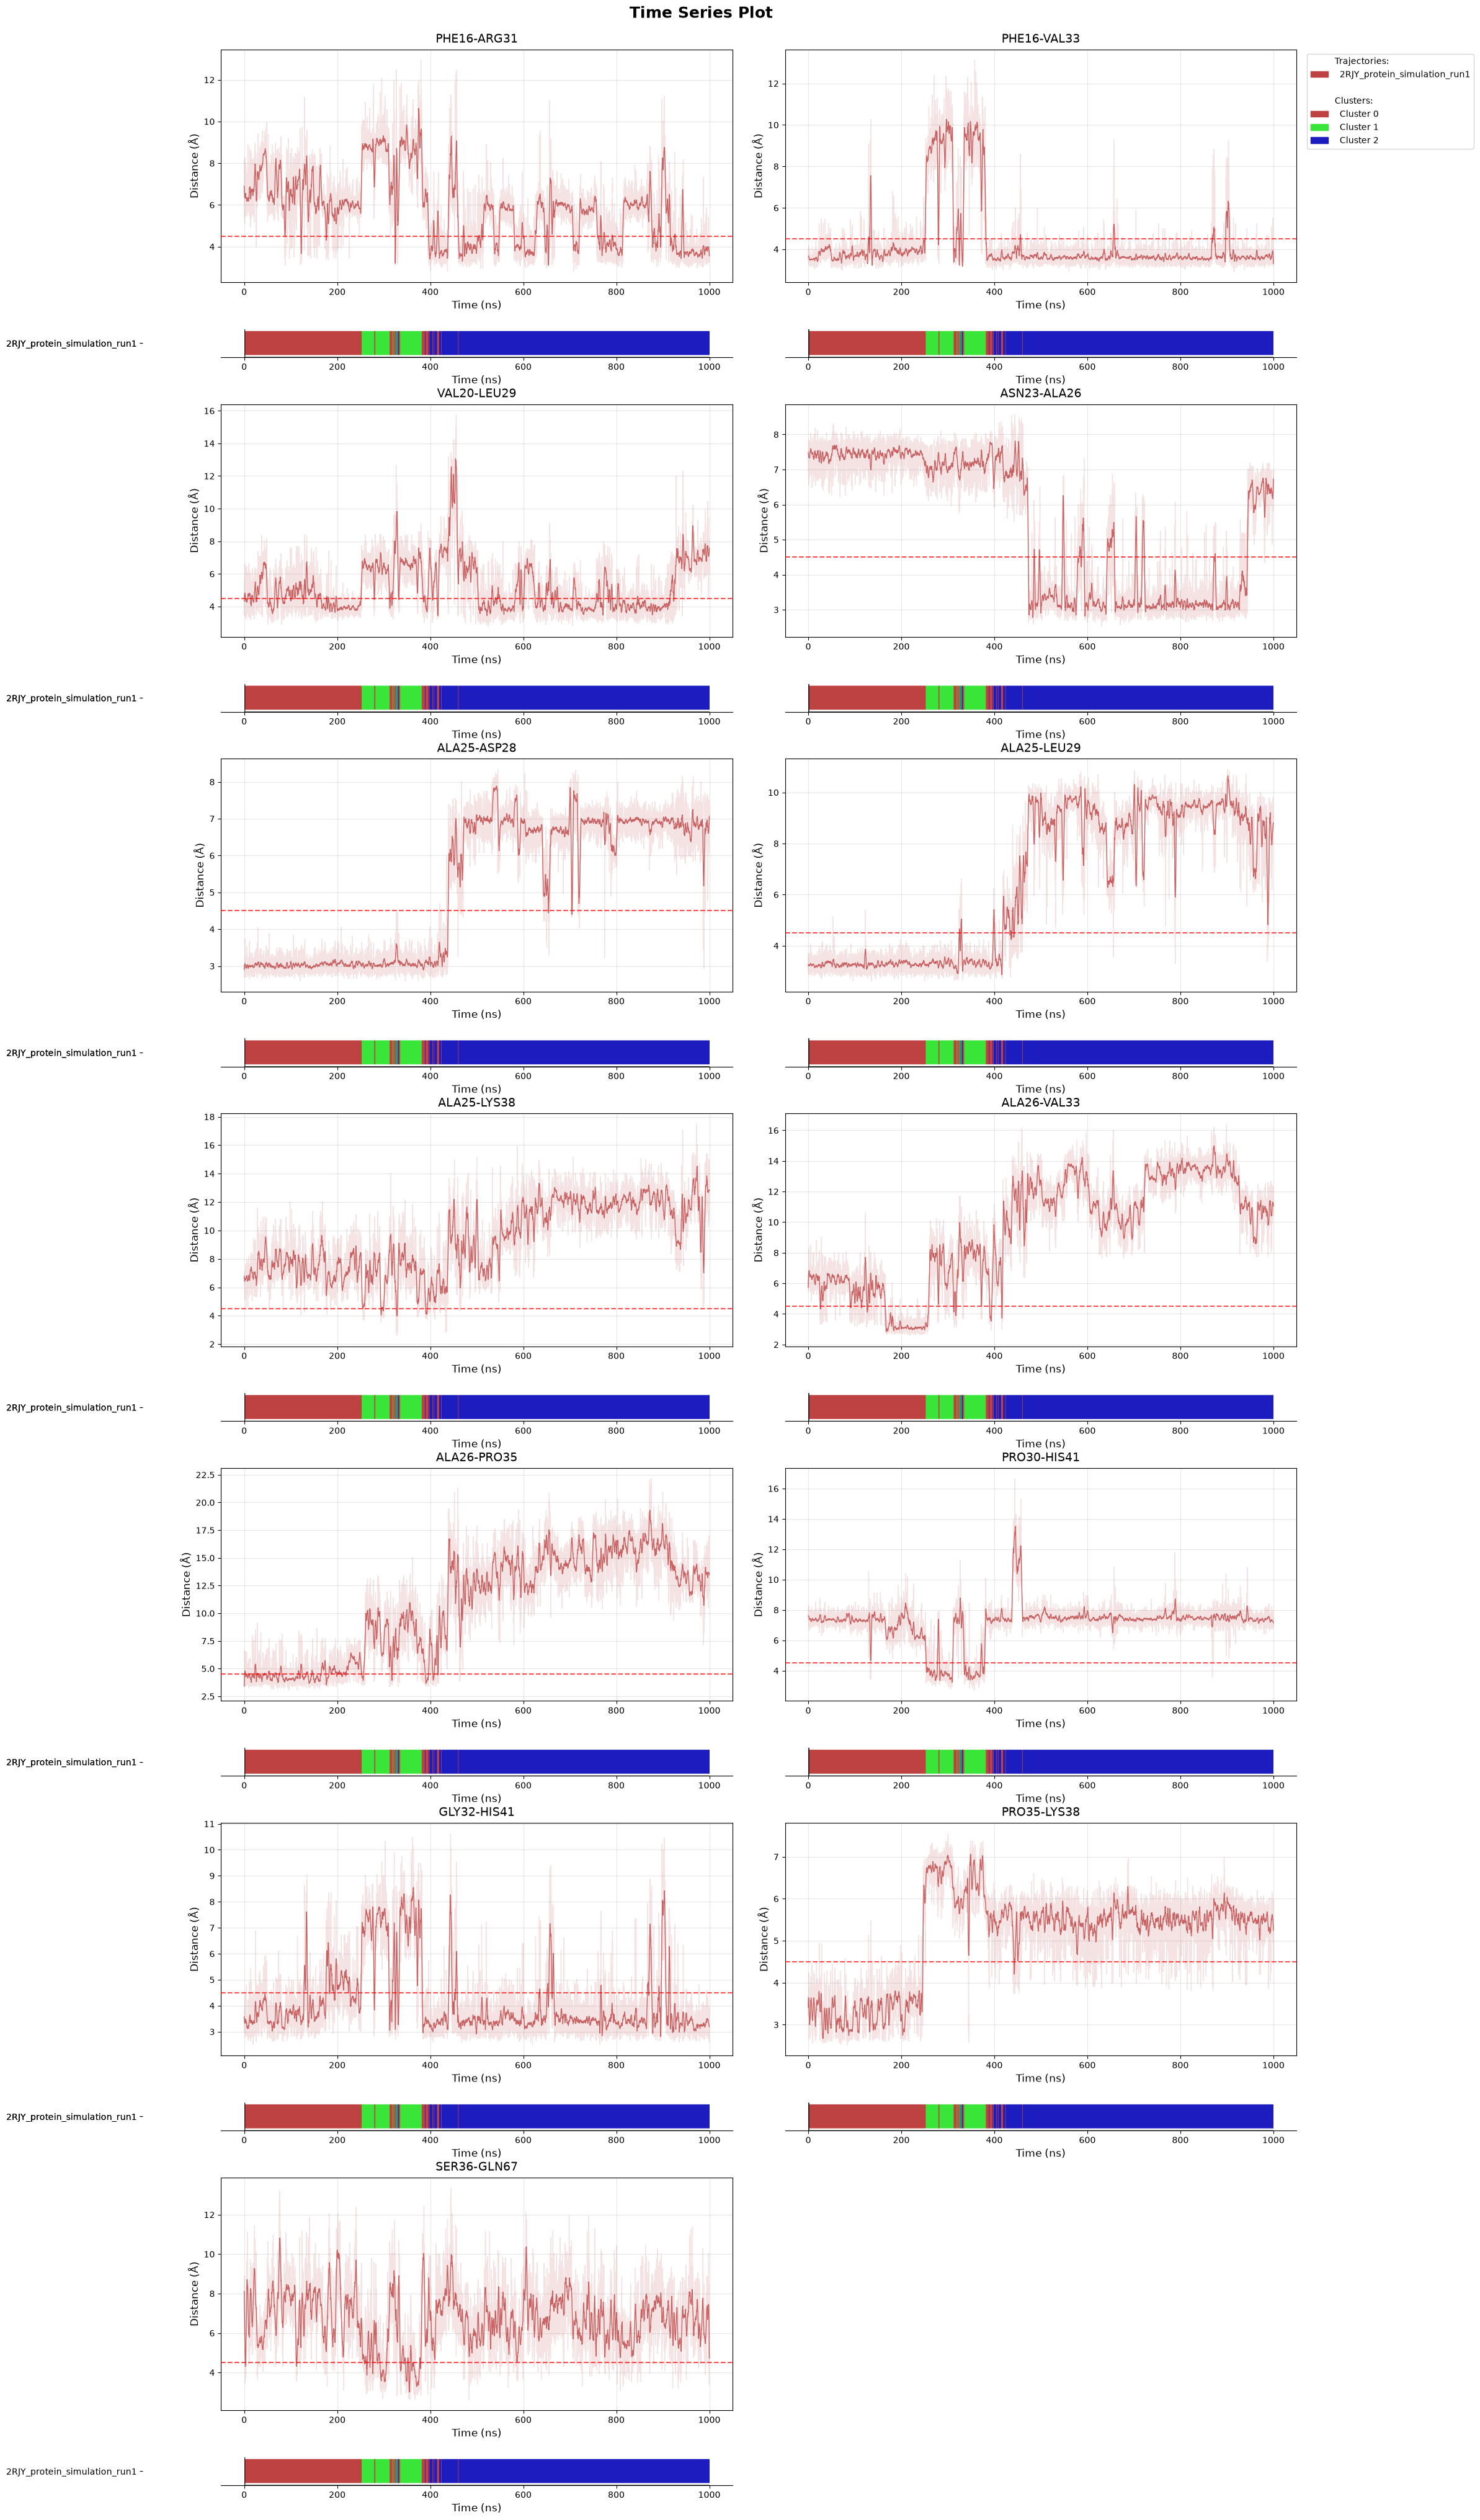

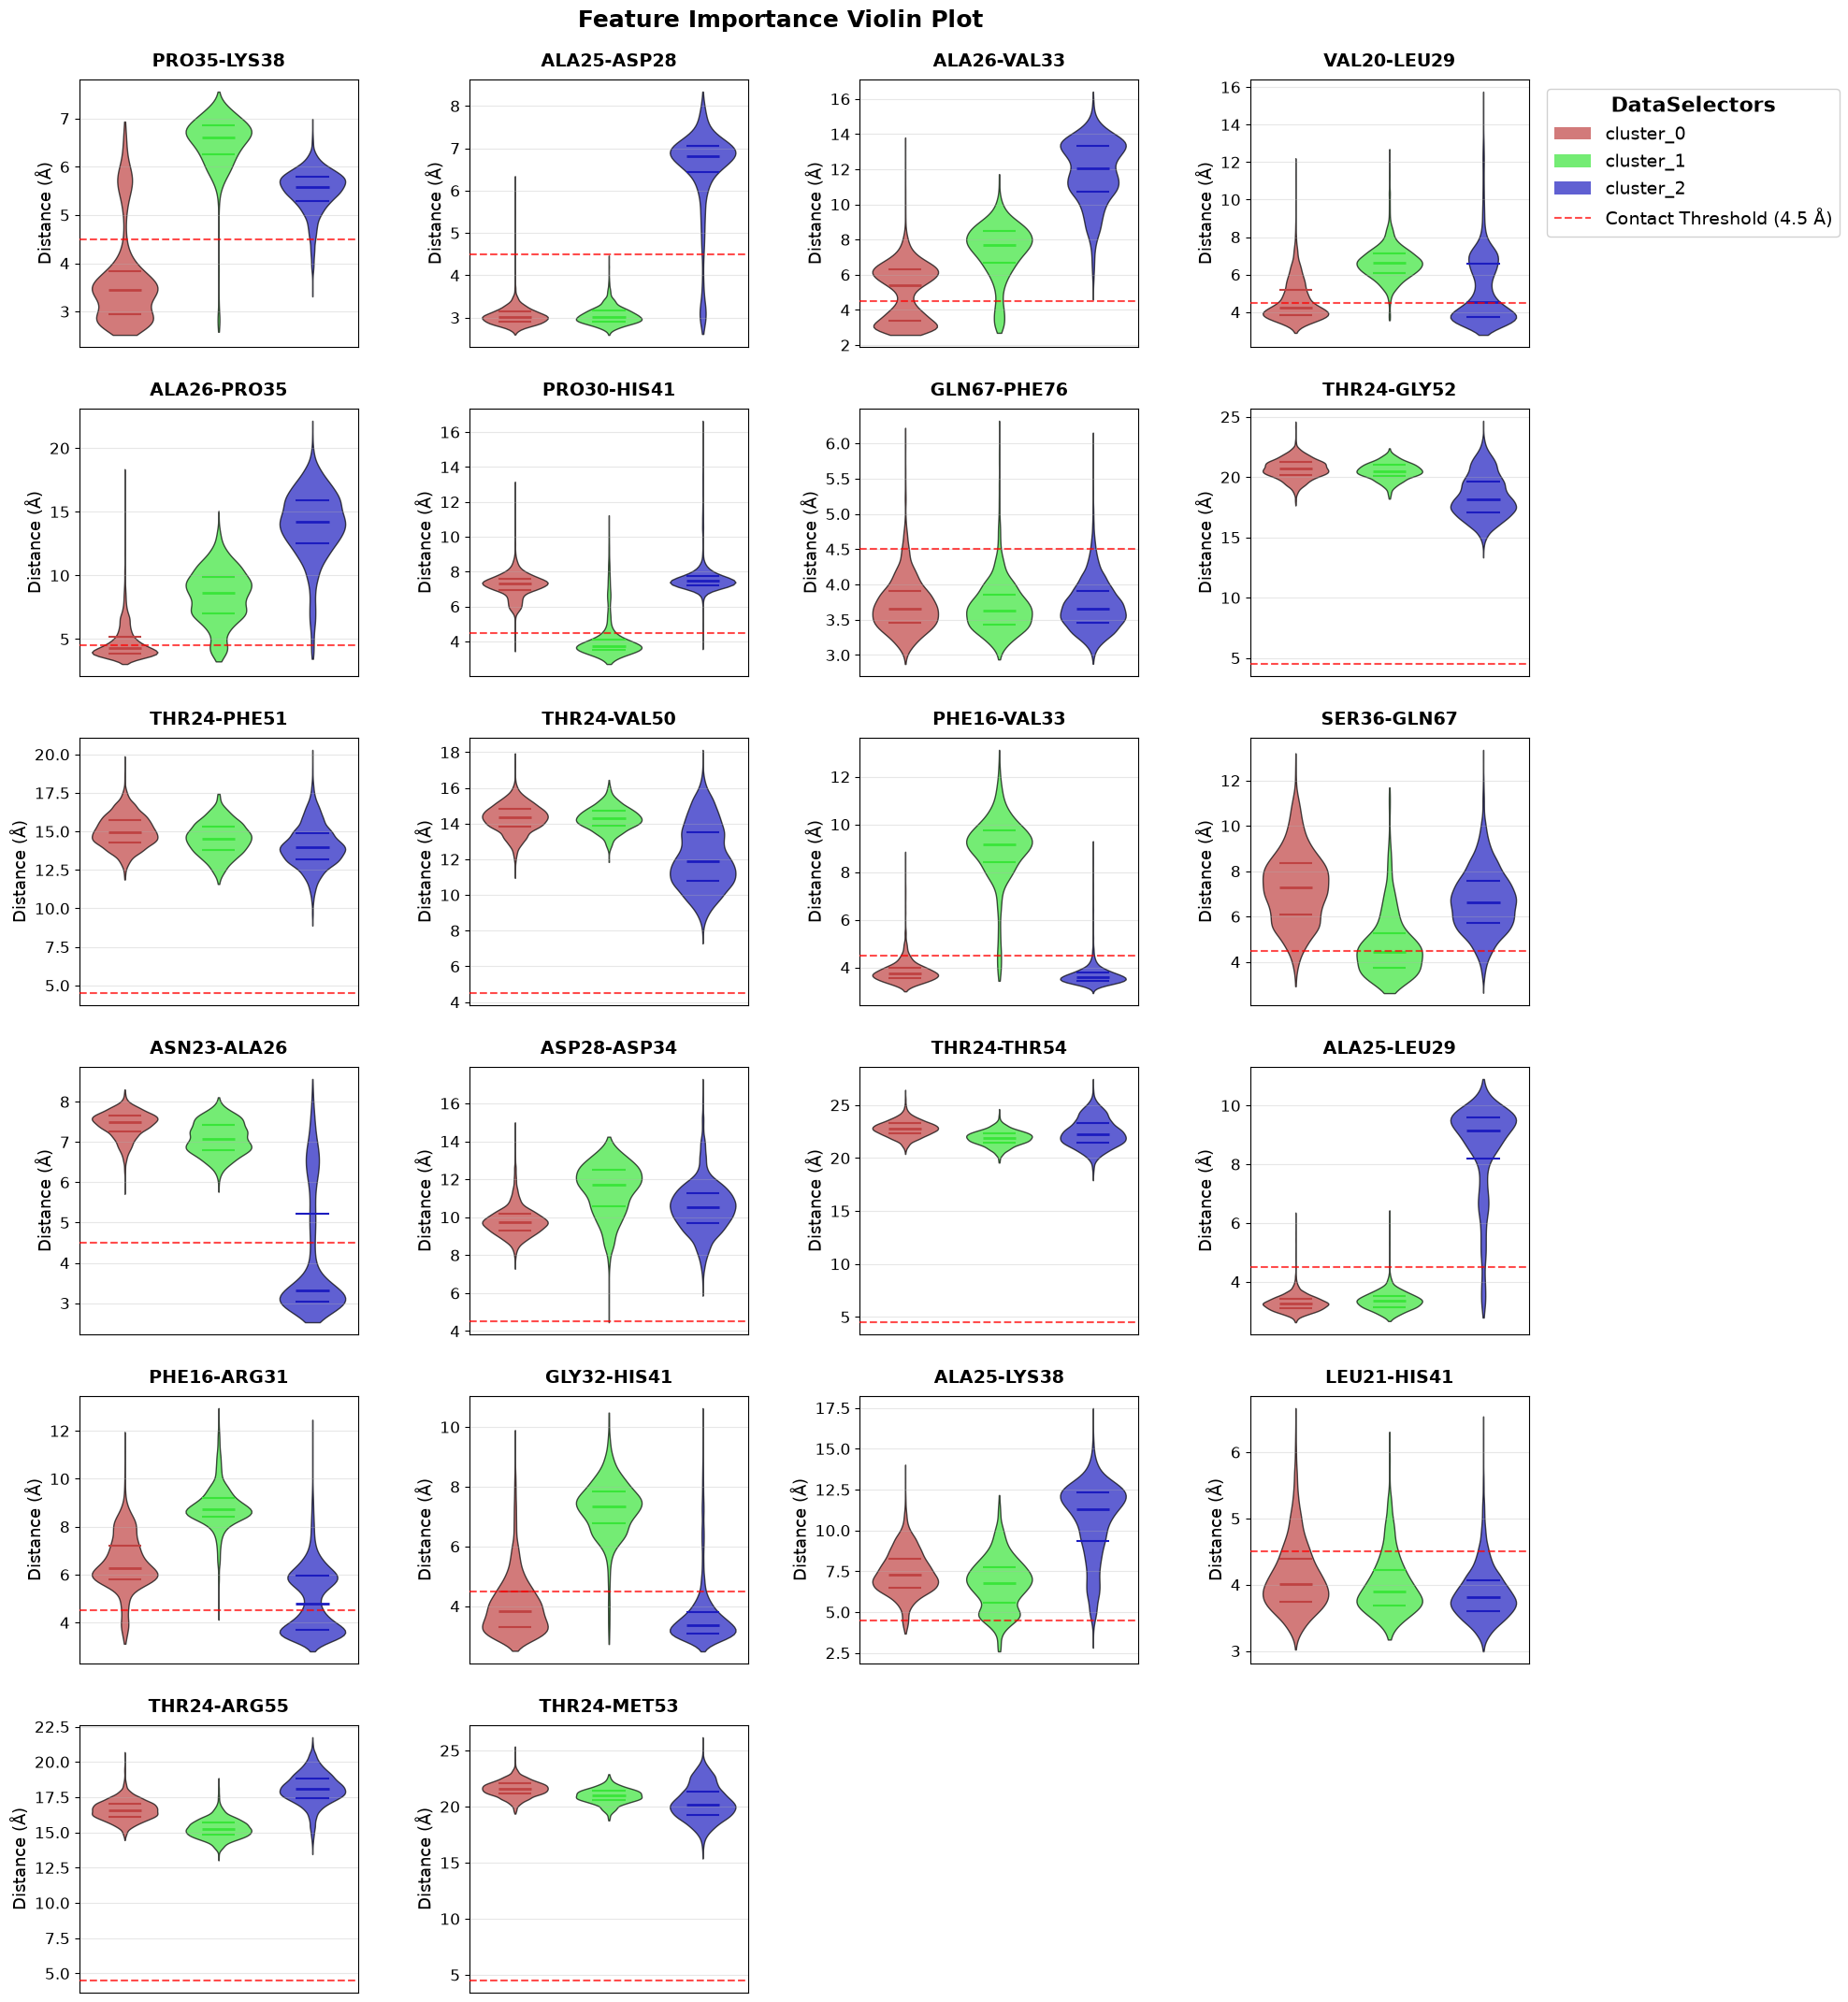

In [23]:
replayed_pipeline = spec_manual.new_pipeline()
replayed_spec = SpecManager()
replayed_spec.read_from_pipeline(replayed_pipeline)

In [24]:
SpecValidatorHelper.compare_specs(spec_manual.data, replayed_spec.data)

{'equal': False,
 'domains': {'pipeline': {'missing_modifiers': [{'mod_name': 'pipeline_init_1',
     'type': 'pipeline_init',
     'config': {'stride': 2,
      'concat': False,
      'selection': None,
      'use_memmap': True,
      'reuse_memmap_cache': False,
      'chunk_size': 2000,
      'dtype': 'float32',
      'cache_dir': './cache',
      'max_memory_gb': 6.0},
     'depends_on': [],
     'depends_on_override': False,
     'order': 1}],
   'extra_modifiers': [{'mod_name': 'pipeline_init_1',
     'type': 'pipeline_init',
     'config': {'stride': 2,
      'concat': False,
      'selection': None,
      'use_memmap': True,
      'reuse_memmap_cache': False,
      'chunk_size': 2000,
      'dtype': 'float32',
      'cache_dir': '/home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_dd39612ec7ad4648875388ba7cfecac2_20261008_132443',
      'max_memory_gb': 6.0},
     'depends_on': [],
     'depends_on_override': False,
     'order': 1}]}}}

# 3. Studies: named, per-domain reference bundles

`studies` groups instance references per domain: `{study_name: {domain: {instance_name: "all" | [mod_name, ...]}}}`. `"all"` is resolved dynamically, not a snapshot.

In [25]:
pipeline_mod_name = spec_manual.data.pipeline["start"]["modifiers"][0]["mod_name"]
traj_mod_names = [m["mod_name"] for m in spec_manual.data.trajectory["trajs"]["modifiers"]]

spec_manual.studies.add_new("study_1")
spec_manual.studies.add_to("study_1", "pipeline", "start")  # default mod_names="all"
spec_manual.studies.add_to(
    "study_1", "trajectory", "trajs", [traj_mod_names[0]]
)  # explicit subset: only the load_trajectories modifier, not add_labels
spec_manual.studies.add_to("study_1", "feature_importance", "feature_importance")

spec_manual.studies.list()

['study_1']

In [26]:
print("study_1:", spec_manual.studies.get("study_1"))

spec_manual.studies.update("study_1", "trajectory", "trajs", traj_mod_names)
print("after update:", spec_manual.studies.get("study_1", "trajectory", "trajs"))

spec_manual.validate()
print("validate() OK")

study_1: {'pipeline': {'start': 'all'}, 'trajectory': {'trajs': ['TrajectoryManager.load_trajectories_1']}, 'feature_importance': {'feature_importance': 'all'}}
after update: ['TrajectoryManager.load_trajectories_1', 'TrajectoryManager.add_labels_1']
validate() OK


In [27]:
spec_manual.studies.remove_from("study_1", "feature_importance")
print("after remove_from (whole domain group):", spec_manual.studies.get("study_1"))

spec_manual.studies.add_new("bad_study")
try:
    spec_manual.studies.add_to("bad_study", "trajectory", "does_not_exist")
except ValueError as e:
    print("expected error (unknown instance):", e)

spec_manual.studies.delete("bad_study")
print("studies after cleanup:", spec_manual.studies.list())

after remove_from (whole domain group): {'pipeline': {'start': 'all'}, 'trajectory': {'trajs': ['TrajectoryManager.load_trajectories_1', 'TrajectoryManager.add_labels_1']}}
expected error (unknown instance): Study 'bad_study' references non-existing instance 'trajectory.does_not_exist'.
studies after cleanup: ['study_1']
